# Treasury Futures Options: Vol Regimes and Market Structure

**Project Statement**

Calibrate the SABR model to options on Treasury note futures across multiple contract months spanning 2025–26. Test whether SABR parameters behave differently in high-volatility vs. calm-market regimes, and compare the dynamics of exchange-traded Treasury options to OTC swaptions from C.8.1.

---

**Team Members:** Adith Srinivasan, Dipesh Ghimire, Eric Beechen, Raghav Prakash

**Course:** FINM 37500 1 Fixed Income Derivatives

In [1]:
import warnings

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import norm
from scipy.stats import pearsonr
from scipy.optimize import brentq, minimize

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.figsize":   (12, 5),
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "legend.fontsize":  10,
})

## Loading and Displaying Treasury Option and Futures Data

In this section, we import the necessary data files containing option surfaces, contract descriptions, and futures data for Treasury note futures. We then display the loaded datasets to review their structure and verify successful import.

#### TY Option Surfaces

In [2]:
# Load the necessary data files from ty_option_surfaces
ty_option_surfaces_file = "data/ty_option_surfaces_p7.xlsx"

# Load the contract descriptions
ty_option_surfaces_descriptions = pd.read_excel(
    ty_option_surfaces_file, sheet_name="descriptions"
)
display(ty_option_surfaces_descriptions.style.set_caption("Contract Descriptions"))


# Load the M2025 data
ty_option_surfaces_M2025 = pd.read_excel(
    ty_option_surfaces_file, sheet_name="CBT TY TY M2025"
)
display(ty_option_surfaces_M2025.head().style.set_caption("CBT TY TY M2025"))


# Load the H2026 data
ty_option_surfaces_H2026 = pd.read_excel(
    ty_option_surfaces_file, sheet_name="CBT TY TY H2026"
)
display(ty_option_surfaces_H2026.head().style.set_caption("CBT TY TY H2026"))


# Load the M2026 data
ty_option_surfaces_M2026 = pd.read_excel(
    ty_option_surfaces_file, sheet_name="CBT TY TY M2026"
)
display(ty_option_surfaces_M2026.head().style.set_caption("CBT TY TY M2026"))

# Load the TY1 futures data
ty_option_surfaces_futures = pd.read_excel(
    ty_option_surfaces_file, sheet_name="TY1 futures"
)
display(ty_option_surfaces_futures.head().style.set_caption("TY1 futures"))

# Load the rates data
ty_option_surfaces_rates = pd.read_excel(
    ty_option_surfaces_file, sheet_name="rates"
)
display(ty_option_surfaces_rates.head().style.set_caption("Rates"))

,specs,CBT TY TY M2025,CBT TY TY H2026,CBT TY TY M2026
0,name,Treasury Notes,Treasury Notes,Treasury Notes
1,exchange,CBT,CBT,CBT
2,futures ticker,TY,TY,TY
3,option ticker,TY,TY,TY
4,monthYear,M2025,H2026,M2026
5,start_date,2025-03-03,2025-11-03,2026-01-02
6,end_date,2025-05-22,2026-02-19,2026-02-27
7,observations,59,78,41


,date,Future Price,Expiration Option,Expiration Future,P15dvol,P20dvol,P25dvol,P30dvol,P35dvol,P40dvol,P45dvol,P50dvol,P55dvol,P60dvol,P65dvol,P70dvol,P75dvol,P80dvol,P85dvol,C15dvol,C20dvol,C25dvol,C30dvol,C35dvol,C40dvol,C45dvol,C50dvol,C55dvol,C60dvol,C65dvol,C70dvol,C75dvol,C80dvol,C85dvol
0,2025-03-03 00:00:00,111.406250,0.222493,0.293151,0.064559,0.063955,0.064298,0.064598,0.064343,0.064261,0.065092,0.065408,0.066358,0.066882,0.067628,0.068128,0.069242,0.070470,0.072362,0.071820,0.070211,0.069009,0.068045,0.067471,0.066791,0.066174,0.065345,0.065008,0.064082,0.064452,0.064605,0.064188,0.063923,0.064771
1,2025-03-04 00:00:00,111.250000,0.219753,0.290411,0.064550,0.064381,0.064131,0.064327,0.064642,0.064417,0.064940,0.065474,0.065587,0.065916,0.066500,0.067053,0.068476,0.069387,0.071460,0.071240,0.069276,0.068101,0.066888,0.066437,0.065766,0.065610,0.065373,0.064835,0.064460,0.064623,0.064260,0.064109,0.064382,0.064867
2,2025-03-05 00:00:00,110.875000,0.217014,0.287671,0.065287,0.064251,0.063971,0.064292,0.064043,0.063703,0.063939,0.064174,0.064338,0.064586,0.065016,0.065825,0.066691,0.067297,0.069274,0.069087,0.067192,0.066547,0.065631,0.064917,0.064533,0.064308,0.064129,0.063894,0.063659,0.064152,0.064297,0.063854,0.064459,0.065507
3,2025-03-06 00:00:00,110.796875,0.214274,0.284932,0.066215,0.066135,0.065760,0.065383,0.065771,0.065666,0.065670,0.065678,0.066173,0.066984,0.067656,0.068404,0.069282,0.069989,0.072119,0.071891,0.069822,0.069136,0.068215,0.067570,0.066816,0.066049,0.065676,0.065670,0.065679,0.065792,0.065290,0.065892,0.066140,0.066519
4,2025-03-07 00:00:00,110.578125,0.211534,0.282192,0.064059,0.063512,0.063925,0.063772,0.063784,0.063880,0.064406,0.064900,0.065090,0.065850,0.066130,0.066752,0.068084,0.069392,0.071203,0.070750,0.069141,0.067846,0.066637,0.066079,0.065739,0.064945,0.064893,0.064261,0.063859,0.063779,0.063805,0.063842,0.063534,0.064403


,date,Future Price,Expiration Option,Expiration Future,P15dvol,P20dvol,P25dvol,P30dvol,P35dvol,P40dvol,P45dvol,P50dvol,P55dvol,P60dvol,P65dvol,P70dvol,P75dvol,P80dvol,P85dvol,C15dvol,C20dvol,C25dvol,C30dvol,C35dvol,C40dvol,C45dvol,C50dvol,C55dvol,C60dvol,C65dvol,C70dvol,C75dvol,C80dvol,C85dvol
0,2025-11-03 00:00:00,112.609375,0.299205,0.375342,0.050809,0.049898,0.049059,0.048668,0.048479,0.048799,0.048669,0.048589,0.048748,0.049272,0.049324,0.050641,0.051574,0.052070,0.054415,0.053696,0.051954,0.051406,0.050222,0.049317,0.049146,0.048639,0.048573,0.048725,0.048722,0.048483,0.048727,0.049166,0.050138,0.051028
1,2025-11-04 00:00:00,112.718750,0.296466,0.372603,0.049827,0.049356,0.048996,0.048603,0.048240,0.048346,0.048843,0.048818,0.049102,0.049893,0.050766,0.051285,0.052365,0.054099,0.055177,0.054900,0.053879,0.052045,0.051160,0.050584,0.049680,0.048923,0.048855,0.048726,0.048281,0.048227,0.048750,0.049031,0.049505,0.049919
2,2025-11-05 00:00:00,112.250000,0.293726,0.369863,0.050609,0.050160,0.049370,0.049073,0.048934,0.048593,0.048668,0.049042,0.049386,0.049690,0.050036,0.050538,0.051506,0.053204,0.055364,0.054570,0.053020,0.051254,0.050421,0.049945,0.049612,0.049318,0.048945,0.048651,0.048592,0.049038,0.049050,0.049584,0.050302,0.050681
3,2025-11-06 00:00:00,112.750000,0.290986,0.367123,0.051772,0.051151,0.050258,0.049822,0.049874,0.049939,0.049983,0.050355,0.050722,0.051286,0.052245,0.052994,0.054180,0.055302,0.056771,0.056337,0.055039,0.053926,0.052761,0.052081,0.051048,0.050646,0.050258,0.049973,0.049927,0.049859,0.049813,0.050492,0.051325,0.052118
4,2025-11-07 00:00:00,112.781250,0.288247,0.364384,0.050784,0.049784,0.050158,0.050128,0.049904,0.050043,0.050156,0.050636,0.051069,0.051765,0.052780,0.053462,0.054061,0.055983,0.058181,0.057559,0.055317,0.053802,0.053368,0.052606,0.051511,0.050978,0.050522,0.050130,0.050017,0.049871,0.050256,0.049993,0.049880,0.051195


,date,Future Price,Expiration Option,Expiration Future,P15dvol,P20dvol,P25dvol,P30dvol,P35dvol,P40dvol,P45dvol,P50dvol,P55dvol,P60dvol,P65dvol,P70dvol,P75dvol,P80dvol,P85dvol,C15dvol,C20dvol,C25dvol,C30dvol,C35dvol,C40dvol,C45dvol,C50dvol,C55dvol,C60dvol,C65dvol,C70dvol,C75dvol,C80dvol,C85dvol
0,2026-01-02 00:00:00,112.093750,0.384137,0.457534,0.049653,0.048650,0.047855,0.047035,0.047060,0.047182,0.047018,0.046648,0.046334,0.046371,0.046487,0.047453,0.048384,0.049920,0.051049,0.050656,0.049680,0.048066,0.047170,0.046455,0.046356,0.046333,0.046769,0.047104,0.047145,0.047043,0.047269,0.048019,0.049104,0.049748
1,2026-01-05 00:00:00,112.296875,0.375918,0.449315,0.049379,0.048357,0.047578,0.047085,0.046647,0.046614,0.046216,0.046692,0.046757,0.047005,0.047630,0.048298,0.049113,0.050404,0.052486,0.051730,0.050043,0.048783,0.048163,0.047419,0.046864,0.046777,0.046558,0.046324,0.046683,0.046634,0.047275,0.047676,0.048629,0.049707
2,2026-01-06 00:00:00,112.203125,0.373178,0.446575,0.047635,0.046882,0.046703,0.046151,0.045510,0.045434,0.045373,0.045922,0.046153,0.046203,0.047010,0.047611,0.048394,0.049169,0.050848,0.050410,0.048534,0.048365,0.047405,0.046833,0.045972,0.046223,0.045723,0.045390,0.045454,0.045570,0.046364,0.046825,0.046970,0.047908
3,2026-01-07 00:00:00,112.453125,0.370438,0.443836,0.047999,0.047615,0.046962,0.046556,0.046362,0.046248,0.046158,0.046104,0.046310,0.047042,0.047569,0.048236,0.048863,0.050316,0.052904,0.052088,0.049847,0.048715,0.048029,0.047454,0.046832,0.046256,0.046091,0.046182,0.046271,0.046401,0.046639,0.047155,0.047744,0.048131
4,2026-01-08 00:00:00,112.125000,0.367699,0.441096,0.048400,0.047253,0.046941,0.046366,0.046030,0.045796,0.045962,0.046133,0.046380,0.046976,0.047717,0.048126,0.049107,0.050693,0.051875,0.051483,0.050453,0.048773,0.048018,0.047525,0.046804,0.046228,0.046106,0.045894,0.045858,0.046117,0.046490,0.047057,0.047512,0.048760


,date,px_last,px_open,px_high,px_low,volume
0,2025-03-03 00:00:00,111.375000,110.984375,111.593750,110.828125,24895
1,2025-03-04 00:00:00,111.218750,111.562500,111.968750,110.968750,20690
2,2025-03-05 00:00:00,110.843750,110.906250,111.453125,110.687500,9145
3,2025-03-06 00:00:00,110.781250,110.640625,110.906250,110.390625,6317
4,2025-03-07 00:00:00,110.546875,110.812500,111.281250,110.468750,8439


,date,SOFR 5Y,SOFR 10Y
0,2025-03-03 00:00:00,3.636300,3.689100
1,2025-03-04 00:00:00,3.713750,3.765100
2,2025-03-05 00:00:00,3.746000,3.801140
3,2025-03-06 00:00:00,3.720000,3.798100
4,2025-03-07 00:00:00,3.744700,3.814200


#### Vol Surfaces

In [3]:
# Load the necessary data files from vol_surfaces
vol_surfaces_file = 'data/vol_surfaces_2025-01-31_M2025.xlsx'

# Load the contract descriptions
vol_surfaces_descriptions = pd.read_excel(
    vol_surfaces_file, sheet_name="descriptions"
)
display(vol_surfaces_descriptions.style.set_caption("Contract Descriptions"))


# Load the Treasury Notes ('TY') options data
vol_surfaces_TY = pd.read_excel(
    vol_surfaces_file, sheet_name="CBT TY TY M2025"
)
display(vol_surfaces_TY.head().style.set_caption("CBT TY TY M2025"))

,specs,CME ES ES M2025,ICE T T M2025,NYM NG NG M2025,CMX GC GC M2025,CME BP BP M2025,CBT TY TY M2025,CBT FF FF M2025
0,name,S&P,Oil,Nat Gas,Gold,British Pounds,Treasury Notes,Fed Funds
1,exchange,CME,ICE,NYM,CMX,CME,CBT,CBT
2,futures ticker,ES,T,NG,GC,BP,TY,FF
3,option ticker,ES,T,NG,GC,BP,TY,FF
4,monthYear,M2025,M2025,M2025,M2025,M2025,M2025,M2025
5,option expiration,2025-06-19,2025-05-14,2025-05-27,2025-05-27,2025-06-06,2025-05-23,2025-07-01
6,future expiration,2025-06-20,2025-05-19,2025-05-28,2025-06-26,2025-06-16,2025-06-18,2025-07-01


,date,Future Price,Expiration Option,Expiration Future,P15dvol,P20dvol,P25dvol,P30dvol,P35dvol,P40dvol,P45dvol,P50dvol,P55dvol,P60dvol,P65dvol,P70dvol,P75dvol,P80dvol,P85dvol,C15dvol,C20dvol,C25dvol,C30dvol,C35dvol,C40dvol,C45dvol,C50dvol,C55dvol,C60dvol,C65dvol,C70dvol,C75dvol,C80dvol,C85dvol
0,2024-09-20 00:00:00,115.625000,0.671808,0.742466,0.070748,0.067907,0.066031,0.064750,0.063866,0.063134,0.063116,0.063148,0.063081,0.063573,0.064427,0.065761,0.067357,0.069727,0.072598,0.070302,0.068004,0.066080,0.064877,0.063867,0.063152,0.063124,0.063137,0.063100,0.063571,0.064377,0.065459,0.067265,0.069438,0.073595
1,2024-09-23 00:00:00,115.625000,0.663589,0.734247,0.070816,0.068121,0.065840,0.064618,0.063764,0.063047,0.063034,0.063069,0.063257,0.063466,0.064289,0.065589,0.067354,0.069364,0.072099,0.070381,0.068108,0.066406,0.064738,0.063763,0.063410,0.063045,0.063055,0.063017,0.063466,0.064248,0.065281,0.066987,0.069530,0.072914
2,2024-09-24 00:00:00,115.671875,0.660849,0.731507,0.070749,0.067843,0.065749,0.064641,0.063867,0.063214,0.062836,0.063005,0.063295,0.063576,0.064486,0.065865,0.067137,0.069174,0.071944,0.070236,0.067902,0.066217,0.064977,0.063904,0.063437,0.063006,0.062875,0.062962,0.063593,0.064303,0.065238,0.066793,0.069383,0.073297
3,2024-09-25 00:00:00,114.921875,0.658110,0.728767,0.066265,0.064788,0.063954,0.063555,0.063287,0.063038,0.063232,0.063537,0.063411,0.063761,0.064227,0.064461,0.065668,0.066684,0.070046,0.067591,0.066130,0.064931,0.064364,0.063930,0.063547,0.063550,0.063370,0.063007,0.063187,0.063437,0.063762,0.064355,0.065822,0.067230
4,2024-09-26 00:00:00,114.765625,0.655370,0.726027,0.067476,0.065797,0.065045,0.064273,0.063730,0.063698,0.063533,0.063907,0.064034,0.064169,0.064380,0.064824,0.065328,0.066530,0.068619,0.067726,0.066081,0.065159,0.064515,0.064238,0.064085,0.063961,0.063682,0.063499,0.063664,0.064042,0.064690,0.065137,0.067074,0.068451


#### Swaption Smile Data

In [4]:
# Load the swaption smile data
swaption_smile_file  = 'data/swaption_smile_daily_2025.xlsx'

# Load the black vols
swaption_smile_black_vol_pct = pd.read_excel(
    swaption_smile_file, sheet_name="black_vol_pct"
)
display(swaption_smile_black_vol_pct.head().style.set_caption("Black Volatility"))


# Load the ATM forward rates
swaption_smile_atm_forward = pd.read_excel(
    swaption_smile_file, sheet_name="atm_forward"
)
display(swaption_smile_atm_forward.head().style.set_caption("ATM Forward Rates"))


# Load the Absolute Strikes
swaption_smile_abs_strike_pct = pd.read_excel(
    swaption_smile_file, sheet_name="absolute_strikes_pct"
)
display(swaption_smile_abs_strike_pct.head().style.set_caption("Absolute Strikes"))

,date,-300,-200,-100,-50,-25,0,25,50,100,200,300
0,2025-04-01 00:00:00,85.670000,51.350000,37.260000,33.060000,31.510000,30.280000,29.350000,28.700000,28.050000,28.310000,29.350000
1,2025-04-02 00:00:00,90.320000,52.760000,37.920000,33.500000,31.850000,30.550000,29.550000,28.850000,28.130000,28.330000,29.360000
2,2025-04-03 00:00:00,110.180000,58.490000,41.330000,36.370000,34.510000,33.040000,31.900000,31.070000,30.150000,30.110000,31.020000
3,2025-04-04 00:00:00,116.600000,60.400000,42.660000,37.590000,35.700000,34.180000,33.010000,32.140000,31.140000,30.970000,31.790000
4,2025-04-07 00:00:00,101.010000,57.840000,41.770000,37.030000,35.240000,33.800000,32.670000,31.820000,30.830000,30.600000,31.370000


,date,atm_fwd_pct
0,2025-04-01 00:00:00,3.570000
1,2025-04-02 00:00:00,3.520000
2,2025-04-03 00:00:00,3.350000
3,2025-04-04 00:00:00,3.310000
4,2025-04-07 00:00:00,3.460000


,date,-300,-200,-100,-50,-25,0,25,50,100,200,300
0,2025-04-01 00:00:00,0.570000,1.570000,2.570000,3.070000,3.320000,3.570000,3.820000,4.070000,4.570000,5.570000,6.570000
1,2025-04-02 00:00:00,0.520000,1.520000,2.520000,3.020000,3.270000,3.520000,3.770000,4.020000,4.520000,5.520000,6.520000
2,2025-04-03 00:00:00,0.350000,1.350000,2.350000,2.850000,3.100000,3.350000,3.600000,3.850000,4.350000,5.350000,6.350000
3,2025-04-04 00:00:00,0.310000,1.310000,2.310000,2.810000,3.060000,3.310000,3.560000,3.810000,4.310000,5.310000,6.310000
4,2025-04-07 00:00:00,0.460000,1.460000,2.460000,2.960000,3.210000,3.460000,3.710000,3.960000,4.460000,5.460000,6.460000


### Standardize dates on all existing DataFrames
We standardize dates, tag each surface DataFrame with its contract label,
and define the delta-column universe used throughout Q1–Q5.

In [5]:
# Standardize dates on all existing DataFrames
for _df in [
    ty_option_surfaces_M2025, ty_option_surfaces_H2026, ty_option_surfaces_M2026,
    ty_option_surfaces_futures, ty_option_surfaces_rates,
    swaption_smile_black_vol_pct, swaption_smile_atm_forward,
    swaption_smile_abs_strike_pct,
]:
    if "date" in _df.columns:
        _df["date"] = pd.to_datetime(_df["date"])
        

# Tag each surface with its contract label
ty_option_surfaces_M2025 = ty_option_surfaces_M2025.copy()
ty_option_surfaces_H2026 = ty_option_surfaces_H2026.copy()
ty_option_surfaces_M2026 = ty_option_surfaces_M2026.copy()

ty_option_surfaces_M2025["contract"] = "M2025"
ty_option_surfaces_H2026["contract"] = "H2026"
ty_option_surfaces_M2026["contract"] = "M2026"


# Identify vol columns
_pat = re.compile(r"^(P|C)(\d+)dvol$")

def _parse_col(c):
    m = _pat.match(str(c))
    return (m.group(1), int(m.group(2))) if m else None

PUT_DELTAS  = [15, 20, 25, 30, 35, 40, 45, 50]   # OTM puts  → K ≤ F
CALL_DELTAS = [15, 20, 25, 30, 35, 40, 45, 50]   # OTM calls → K ≥ F
PUT_COLS  = [f"P{d}dvol" for d in PUT_DELTAS]
CALL_COLS = [f"C{d}dvol" for d in CALL_DELTAS]

## Question 1 – Implied Vol Surface Construction

TY options are quoted in delta space (e.g., P25dvol = 25-delta put implied vol).  
We convert to strike space by inverting the Black delta formula for options on futures.

**Delta-to-strike inversion (no cost-of-carry on futures):**

For a **put** with absolute delta $q \in (0,1)$ and Black vol $\sigma$:

- $d_1 = \dfrac{\ln F/K + \frac{1}{2}\sigma^2T}{\sigma\sqrt{T}}$
- $|\Delta_P| = N(-d_1) = q$
- $\implies d_1 = -\Phi^{-1}(q)$
- $\implies K = F \cdot \exp\left(\Phi^{-1}(q)\cdot\sigma\sqrt{T} + \frac{1}{2}\sigma^2 T\right)$

For a **call** with delta $q \in (0,1)$:

- $\Delta_C = N(d_1) = q \implies d_1 = \Phi^{-1}(q)$
- $\implies K = F \cdot \exp\left(-\Phi^{-1}(q)\cdot\sigma\sqrt{T} + \frac{1}{2}\sigma^2T\right)$

ATM vol used throughout: average of P50dvol and C50dvol.

In [6]:
# Helper functions used throughout the project
def put_strike(F, sigma, T, q):
    """Strike for OTM put with absolute delta q = |Δ_P| = N(–d₁)."""
    if sigma <= 0 or T <= 0 or not (0 < q < 1):
        return np.nan
    return F * np.exp(norm.ppf(q) * sigma * np.sqrt(T) + 0.5 * sigma**2 * T)


def call_strike(F, sigma, T, q):
    """Strike for OTM call with delta q = Δ_C = N(d₁)."""
    if sigma <= 0 or T <= 0 or not (0 < q < 1):
        return np.nan
    return F * np.exp(-norm.ppf(q) * sigma * np.sqrt(T) + 0.5 * sigma**2 * T)


def build_smile(row, put_cols=PUT_COLS, call_cols=CALL_COLS):
    """
    Convert one TY surface row (delta vols) into a strike-based smile DataFrame.
    Uses OTM puts (P15–P50) for left wing and OTM calls (C15–C50) for right wing.
    P50 / C50 are averaged into a single ATM point.
    """
    F = float(row["Future Price"])
    T = float(row["Expiration Option"])
    records = []

    for col in put_cols:
        q = int(re.search(r"\d+", col).group()) / 100.0
        sigma = float(row[col])
        if np.isnan(sigma) or sigma <= 0:
            continue
        K = put_strike(F, sigma, T, q)
        records.append({"side": "P", "delta": q, "strike": K, "vol": sigma})

    for col in call_cols:
        q = int(re.search(r"\d+", col).group()) / 100.0
        sigma = float(row[col])
        if np.isnan(sigma) or sigma <= 0:
            continue
        K = call_strike(F, sigma, T, q)
        records.append({"side": "C", "delta": q, "strike": K, "vol": sigma})

    df = pd.DataFrame(records)

    # Average P50 / C50 into a single ATM point
    atm = df[df["delta"] == 0.50]
    if len(atm) >= 2:
        atm_row = {
            "side": "ATM", "delta": 0.50,
            "strike": atm["strike"].mean(),
            "vol":    atm["vol"].mean(),
        }
        df = pd.concat([df[df["delta"] != 0.50],
                        pd.DataFrame([atm_row])], ignore_index=True)

    df["Future_Price"] = F
    df["T"] = T
    df["date"] = row["date"]
    return df.sort_values("strike").reset_index(drop=True)


def atm_vol_from_row(row):
    """Average P50 and C50 as the ATM vol estimate."""
    p50 = float(row["P50dvol"]) if "P50dvol" in row.index else np.nan
    c50 = float(row["C50dvol"]) if "C50dvol" in row.index else np.nan
    vals = [v for v in [p50, c50] if np.isfinite(v) and v > 0]
    return np.mean(vals) if vals else np.nan

### Q1. a) – Strike Smile for a Representative Early M2025 Date

We take the first date in the M2025 sample (2025-03-03), invert the delta
formula for every available point, and display implied vol vs. strike.

,side,delta,strike,vol_pct
0,P,0.15,107.9951,6.4559%
1,P,0.20,108.6628,6.3955%
2,P,0.25,109.2006,6.4298%
3,P,0.30,109.6912,6.4598%
4,P,0.35,110.1617,6.4343%
5,P,0.40,110.6048,6.4261%
6,P,0.45,111.0296,6.5092%
7,ATM,0.50,111.4592,6.5376%
8,C,0.45,111.8986,6.6174%
9,C,0.40,112.3548,6.6791%


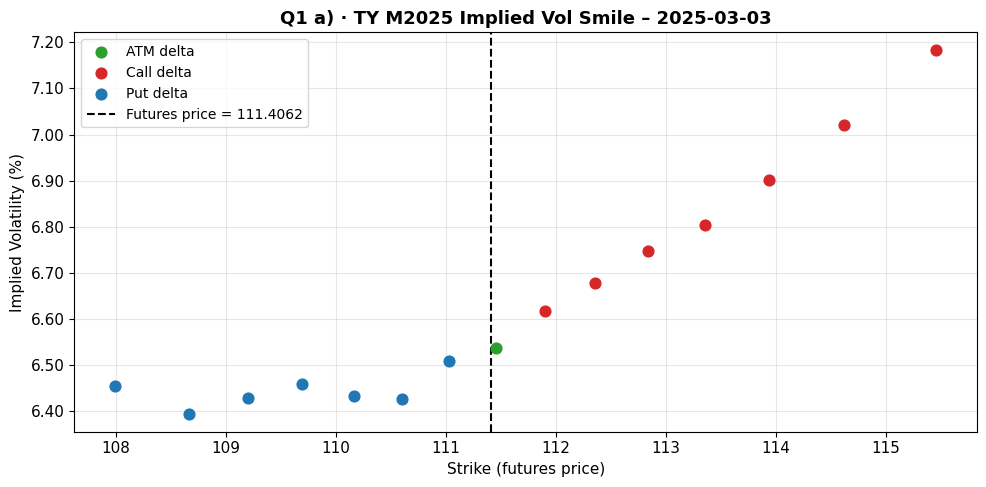

,ATM vol (avg P50/C50) [%],Strike min,Strike max
0,6.5377%,107.9951,115.4536


In [7]:
q1a_row  = ty_option_surfaces_M2025.sort_values("date").iloc[0]
q1a_date = q1a_row["date"]
q1a_smile = build_smile(q1a_row)
q1a_F     = q1a_row["Future Price"]
q1a_atm   = atm_vol_from_row(q1a_row)

# Display smile table
display(
    q1a_smile[["side", "delta", "strike", "vol"]]
    .assign(vol_pct=lambda d: (d["vol"] * 100).round(4))
    .drop(columns="vol")
    .style.set_caption(f"Q1 a) · TY M2025 Strike Smile – {q1a_date.date()}")
    .format({"strike": "{:.4f}", "vol_pct": "{:.4f}%", "delta": "{:.2f}"})
)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
colors = {"P": "#1f77b4", "C": "#d62728", "ATM": "#2ca02c"}
for side, grp in q1a_smile.groupby("side"):
    ax.scatter(grp["strike"], grp["vol"] * 100,
               color=colors.get(side, "grey"), s=60,
               label=f"{'Put' if side=='P' else 'Call' if side=='C' else 'ATM'} delta",
               zorder=3)

ax.axvline(q1a_F, color="black", ls="--", lw=1.5,
           label=f"Futures price = {q1a_F:.4f}")
ax.set_title(f"Q1 a) · TY M2025 Implied Vol Smile – {q1a_date.date()}")
ax.set_xlabel("Strike (futures price)")
ax.set_ylabel("Implied Volatility (%)")
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.2f"))
ax.legend(); fig.tight_layout(); plt.show()

# Summary table
summary_df = pd.DataFrame({
    "ATM vol (avg P50/C50) [%]": [f"{q1a_atm*100:.4f}%"],
    "Strike min": [f"{q1a_smile['strike'].min():.4f}"],
    "Strike max": [f"{q1a_smile['strike'].max():.4f}"]
})
display(
    summary_df.style.set_caption("Q1 a) · TY M2025 ATM Vol and Strike Range")
)

### Q1. b) – Smile Evolution Around the April 2025 Tariff Episode

Dates chosen:
- **Before (Apr 2)**: day before tariff announcement
- **Shock (Apr 3)**: Liberation Day tariff shock, flight-to-safety
- **Pause (Apr 9)**: 90-day tariff pause announced; yields reversed

We examine both the level shift *and* the shape change.

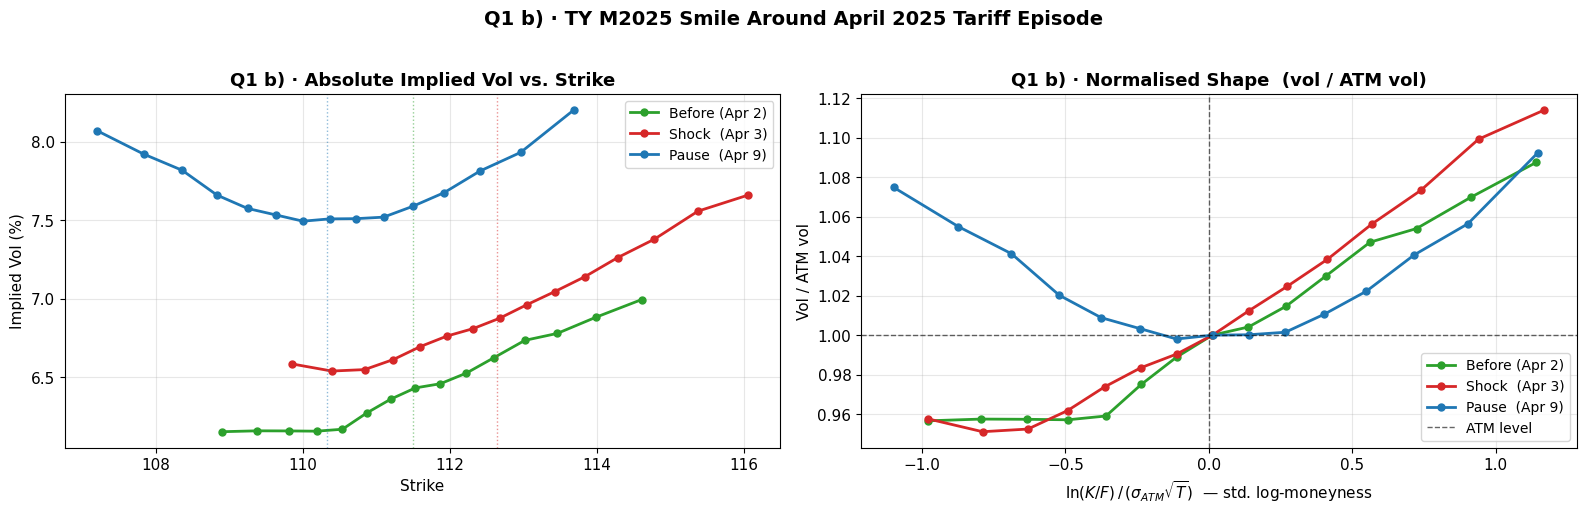

,Date,Futures Price,ATM Vol (%),25Δ RR = P25–C25 (vol%),25Δ Butterfly (vol%)
Event,,,,,
Before (Apr 2),2025-04-02,111.500000,6.432600,-0.621300,0.036600
Shock (Apr 3),2025-04-03,112.640625,6.876200,-0.830700,0.088500
Pause (Apr 9),2025-04-09,110.328125,7.509400,0.004600,0.307400


In [8]:
TARIFF_DATES = {
    "Before (Apr 2)": pd.Timestamp("2025-04-02"),
    "Shock  (Apr 3)": pd.Timestamp("2025-04-03"),
    "Pause  (Apr 9)": pd.Timestamp("2025-04-09"),
}

_avail = ty_option_surfaces_M2025["date"].sort_values().values

def nearest_date(target, available):
    idx = np.argmin(np.abs(pd.to_datetime(available) - target))
    return pd.Timestamp(available[idx])

tariff_smiles = {}
tariff_rows   = {}
for label, target in TARIFF_DATES.items():
    dt  = nearest_date(target, _avail)
    row = ty_option_surfaces_M2025[ty_option_surfaces_M2025["date"] == dt].iloc[0]
    tariff_smiles[label] = build_smile(row)
    tariff_rows[label]   = row
    
# Panel plot: absolute vols & normalised by ATM vol
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
PALETTE = ["#2ca02c", "#d62728", "#1f77b4"]

# Absolute levels
ax = axes[0]
for (label, smile), color in zip(tariff_smiles.items(), PALETTE):
    row = tariff_rows[label]
    ax.plot(smile["strike"], smile["vol"] * 100, "o-",
            color=color, lw=2, ms=5, label=label)
    ax.axvline(row["Future Price"], color=color, ls=":", lw=1, alpha=0.5)
ax.set_title("Q1 b) · Absolute Implied Vol vs. Strike")
ax.set_xlabel("Strike"); ax.set_ylabel("Implied Vol (%)"); ax.legend()

# Vol / ATM vol vs. log-moneyness (normalised shape comparison)
ax = axes[1]
for (label, smile), color in zip(tariff_smiles.items(), PALETTE):
    row = tariff_rows[label]
    F_   = row["Future Price"]
    sig_ = atm_vol_from_row(row)
    T_   = row["Expiration Option"]
    x = np.log(smile["strike"] / F_) / (sig_ * np.sqrt(T_))
    y = smile["vol"] / sig_
    ax.plot(x, y, "o-", color=color, lw=2, ms=5, label=label)

ax.axhline(1, color="black", ls="--", lw=1, alpha=0.6, label="ATM level")
ax.axvline(0, color="black", ls="--", lw=1, alpha=0.6)
ax.set_title("Q1 b) · Normalised Shape  (vol / ATM vol)")
ax.set_xlabel(r"$\ln(K/F)\,/\,(\sigma_{ATM}\sqrt{T})$  — std. log-moneyness")
ax.set_ylabel("Vol / ATM vol"); ax.legend()


fig.suptitle("Q1 b) · TY M2025 Smile Around April 2025 Tariff Episode",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout(); plt.show()

# Summary table: ATM vol, 25-delta RR, 25-delta Fly
recs = []
for label, row in tariff_rows.items():
    atm  = atm_vol_from_row(row)
    p25  = float(row["P25dvol"]) if "P25dvol" in row.index else np.nan
    c25  = float(row["C25dvol"]) if "C25dvol" in row.index else np.nan
    rr25 = (p25 - c25) * 100        if (np.isfinite(p25) and np.isfinite(c25)) else np.nan
    fly25= ((p25 + c25) / 2 - atm) * 100 if (np.isfinite(p25) and np.isfinite(c25)) else np.nan
    recs.append({
        "Event": label, "Date": row["date"].date(),
        "Futures Price": row["Future Price"],
        "ATM Vol (%)": round(atm * 100, 4),
        "25Δ RR = P25–C25 (vol%)": round(rr25, 4) if np.isfinite(rr25) else np.nan,
        "25Δ Butterfly (vol%)": round(fly25, 4) if np.isfinite(fly25) else np.nan,
    })
display(
    pd.DataFrame(recs).set_index("Event")
    .style.set_caption("Q1 b) · Smile Characteristics Around Tariff Episode")
)

### Check exact days

### Q1. c) – TY Futures Options vs. 1Yx5Y Swaptions: Before / Shock / Pause

We compare TY M2025 options against the 1Yx5Y swaption smile from C.8.1 on all
three dates used in Q1. b). Because the two products have very different ATM levels
(~111 futures price vs ~3.35–3.57% yield), a raw vol comparison is meaningless.

**Normalisation:**
  - **y-axis**: vol / σ<sub>ATM</sub>  (removes the level, isolates shape)
  - **x-axis**: ln(K/F) / (σ<sub>ATM</sub> √T)  (standardised log-moneyness in σ units)

This common shape grid reveals differences in **skew** (left/right asymmetry,
driven by ρ) and **curvature** (wing fatness, driven by ν) across the two markets
as the tariff episode unfolds.

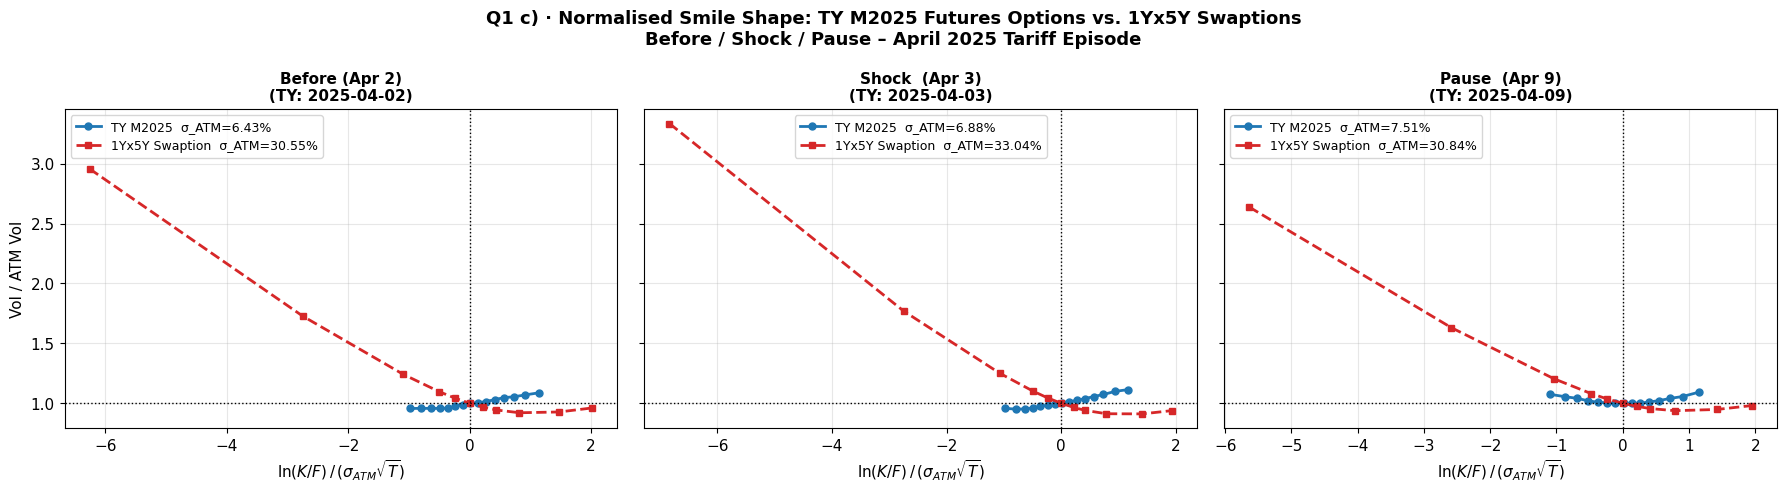

,TY Date,SW Date,TY ATM Vol (%),SW ATM Vol (%),TY Norm 25Δ RR,SW Norm 25Δ RR,TY Norm 25Δ Fly,SW Norm 25Δ Fly
Event,,,,,,,,
Before (Apr 2),2025-04-02,2025-04-02,6.4326,30.5500,-0.0966,0.0753,0.0057,0.0049
Shock (Apr 3),2025-04-03,2025-04-03,6.8762,33.0400,-0.1208,0.0790,0.0129,0.0050
Pause (Apr 9),2025-04-09,2025-04-09,7.5094,30.8400,0.0006,0.0616,0.0409,0.0045


In [9]:
# Identify the ATM (moneyness = 0 bp) column in swaption data
_sw_mono_cols = [c for c in swaption_smile_black_vol_pct.columns if c != "date"]

def _find_sw_atm_col(cols):
    """Return the column whose integer value is 0 (ATM moneyness)."""
    for c in cols:
        try:
            if int(c) == 0:
                return c
        except (ValueError, TypeError):
            pass
    raise KeyError("Cannot locate ATM (moneyness=0) column in swaption vol data.")

_sw_atm_col = _find_sw_atm_col(_sw_mono_cols)


def build_sw_smile_arrays(dt):
    """Return (strikes_dec, vols_dec, F_dec, T, atm_vol_dec) for a swaption date."""
    vr = swaption_smile_black_vol_pct[swaption_smile_black_vol_pct["date"] == dt].iloc[0]
    fr = swaption_smile_atm_forward  [swaption_smile_atm_forward  ["date"] == dt].iloc[0]
    sr = swaption_smile_abs_strike_pct[swaption_smile_abs_strike_pct["date"] == dt].iloc[0]
    strikes  = np.array([float(sr[c]) / 100.0 for c in _sw_mono_cols])
    vols     = np.array([float(vr[c]) / 100.0 for c in _sw_mono_cols])
    F        = float(fr["atm_fwd_pct"]) / 100.0
    atm_vol  = float(vr[_sw_atm_col])  / 100.0
    return strikes, vols, F, 1.0, atm_vol   # T = 1 year for 1Yx5Y


# Three-panel normalised overlay
EVENT_LABELS = list(TARIFF_DATES.keys())
sw_avail     = swaption_smile_black_vol_pct["date"].values

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
comp_records = []

for ax, label in zip(axes, EVENT_LABELS):
    ty_dt = nearest_date(TARIFF_DATES[label], _avail)

    # TY smile
    ty_r    = ty_option_surfaces_M2025[ty_option_surfaces_M2025["date"] == ty_dt].iloc[0]
    ty_sm   = build_smile(ty_r)
    ty_F_   = ty_r["Future Price"]
    ty_T_   = ty_r["Expiration Option"]
    ty_atm_ = atm_vol_from_row(ty_r)
    ty_x    = np.log(ty_sm["strike"] / ty_F_) / (ty_atm_ * np.sqrt(ty_T_))
    ty_y    = ty_sm["vol"] / ty_atm_
    ax.plot(ty_x, ty_y, "o-", color="#1f77b4", lw=2, ms=5,
            label=f"TY M2025  σ_ATM={ty_atm_*100:.2f}%")

    # Swaption smile (match nearest available date, tol ≤ 2 days)
    sw_dt = nearest_date(ty_dt, sw_avail)
    has_sw = abs((sw_dt - ty_dt).days) <= 2

    if has_sw:
        sw_K_, sw_v_, sw_F_, sw_T_, sw_atm_ = build_sw_smile_arrays(sw_dt)
        sw_x = np.log(sw_K_ / sw_F_) / (sw_atm_ * np.sqrt(sw_T_))
        sw_y = sw_v_ / sw_atm_
        ax.plot(sw_x, sw_y, "s--", color="#d62728", lw=2, ms=5,
                label=f"1Yx5Y Swaption  σ_ATM={sw_atm_*100:.2f}%")

        # Shape metrics for the comparison table
        # TY: use P25/C25 delta points directly
        p25_v = ty_sm.loc[(ty_sm["side"]=="P") & ty_sm["delta"].between(0.249,0.251), "vol"]
        c25_v = ty_sm.loc[(ty_sm["side"]=="C") & ty_sm["delta"].between(0.249,0.251), "vol"]
        ty_rr  = ((p25_v.mean() - c25_v.mean()) / ty_atm_
                   if (len(p25_v) and len(c25_v)) else np.nan)
        ty_fly = (((p25_v.mean() + c25_v.mean()) / 2 - ty_atm_) / ty_atm_
                   if (len(p25_v) and len(c25_v)) else np.nan)

        # Swaption: interpolate at ATM ± 25 bp in rate space
        sw_atm_abs = sw_F_
        sw_v_m25   = np.interp(sw_atm_abs - 0.0025, sw_K_, sw_v_)
        sw_v_p25   = np.interp(sw_atm_abs + 0.0025, sw_K_, sw_v_)
        sw_rr  = (sw_v_m25 - sw_v_p25) / sw_atm_
        sw_fly = ((sw_v_m25 + sw_v_p25) / 2 - sw_atm_) / sw_atm_
    else:
        sw_atm_ = np.nan
        ty_rr = ty_fly = sw_rr = sw_fly = np.nan

    comp_records.append({
        "Event":             label,
        "TY Date":           ty_dt.date(),
        "SW Date":           sw_dt.date() if has_sw else "n/a",
        "TY ATM Vol (%)":    round(ty_atm_ * 100, 4),
        "SW ATM Vol (%)":    round(sw_atm_ * 100, 4) if has_sw else np.nan,
        "TY Norm 25Δ RR":   round(ty_rr,  4) if np.isfinite(ty_rr)  else np.nan,
        "SW Norm 25Δ RR":   round(sw_rr,  4) if np.isfinite(sw_rr)  else np.nan,
        "TY Norm 25Δ Fly":  round(ty_fly, 4) if np.isfinite(ty_fly) else np.nan,
        "SW Norm 25Δ Fly":  round(sw_fly, 4) if np.isfinite(sw_fly) else np.nan,
    })

    ax.axhline(1, color="black", ls=":", lw=1)
    ax.axvline(0, color="black", ls=":", lw=1)
    ax.set_title(f"{label.strip()}\n(TY: {ty_dt.date()})", fontsize=11)
    ax.set_xlabel(r"$\ln(K/F)\,/\,(\sigma_{ATM}\sqrt{T})$")
    ax.legend(fontsize=9)

axes[0].set_ylabel("Vol / ATM Vol")
fig.suptitle(
    "Q1 c) · Normalised Smile Shape: TY M2025 Futures Options vs. 1Yx5Y Swaptions\n"
    "Before / Shock / Pause – April 2025 Tariff Episode",
    fontsize=13, fontweight="bold"
)
fig.tight_layout(); plt.show()

# Shape-metrics comparison table
display(
    pd.DataFrame(comp_records).set_index("Event")
    .style.set_caption(
        "Q1 c) · Smile Shape Metrics: TY Options vs. 1Yx5Y Swaptions Across Tariff Dates\n"
        "(Norm. RR = (P25–C25)/σ_ATM;  Norm. Fly = (avg wing – ATM)/σ_ATM)")
    .format({c: "{:.4f}" for c in [
        "TY ATM Vol (%)","SW ATM Vol (%)",
        "TY Norm 25Δ RR","SW Norm 25Δ RR",
        "TY Norm 25Δ Fly","SW Norm 25Δ Fly"]}, na_rep="n/a")
)

### Different normalization for comparison

## Question 2 – SABR Calibration

**SABR model** (Hagan et al. 2002, β = 0.5 fixed):

$$
\sigma_B(K, F) = \frac{\alpha}{(F K)^{(1-\beta)/2} \cdot D} \cdot \frac{z}{\chi(z)} \cdot \left[1 + \Lambda \cdot T \right]
$$

where

$$
z = \frac{\nu}{\alpha} (F K)^{(1-\beta)/2} \ln\left(\frac{F}{K}\right)
$$

$$
\chi(z) = \ln\left( \frac{\sqrt{1 - 2\rho z + z^2} + z - \rho}{1 - \rho} \right)
$$

$$
D = 1 + \frac{(1-\beta)^2}{24}\left[\ln\left(\frac{F}{K}\right)\right]^2 + \frac{(1-\beta)^4}{1920}\left[\ln\left(\frac{F}{K}\right)\right]^4
$$

$$
\Lambda = \frac{(1-\beta)^2}{24}\frac{\alpha^2}{(F K)^{1-\beta}}
+ \frac{\rho\beta\nu\alpha}{4 (F K)^{(1-\beta)/2}}
+ \frac{2 - 3\rho^2}{24} \nu^2
$$

**ATM constraint:** Set \(K=F\), which gives the following limit:

$$
\sigma_{ATM} = \frac{\alpha}{F^{1-\beta}} \left[1 + \Lambda_{ATM} \cdot T\right]
$$

where

$$
\Lambda_{ATM} = \frac{(1-\beta)^2 \alpha^2}{24 F^{2-2\beta}}
+ \frac{\rho \beta \nu \alpha}{4 F^{1-\beta}}
+ \frac{2 - 3\rho^2}{24}\nu^2
$$

**Calibration strategy:**  
Solve for $(\alpha$) analytically or numerically from the ATM constraint at each $((\nu, \rho)$) trial, then optimize the SSE over $((\nu, \rho)$) only.

In [10]:
# Helper functions for SABR calibration
BETA = 0.5

def sabr_atm_vol(F, T, alpha, beta, rho, nu):
    """Hagan ATM SABR vol (K → F limit)."""
    omB = 1.0 - beta
    Fb  = F ** omB
    lam = (
        omB**2 / 24.0 * alpha**2 / F**(2 * omB)
        + rho * beta * nu * alpha / (4.0 * Fb)
        + (2.0 - 3.0 * rho**2) / 24.0 * nu**2
    )
    return (alpha / Fb) * (1.0 + lam * T)


def sabr_implied_vol(F, K, T, alpha, beta, rho, nu):
    """Hagan et al. 2002 lognormal SABR approximation."""
    if alpha <= 0 or nu <= 0 or not (-1 < rho < 1):
        return np.nan
    if T <= 0:
        return np.nan

    omB    = 1.0 - beta
    logFK  = np.log(F / K)

    # ATM limit
    if abs(logFK) < 1e-8:
        return sabr_atm_vol(F, T, alpha, beta, rho, nu)

    FK_mid = (F * K) ** (omB / 2.0)
    z      = nu / alpha * FK_mid * logFK
    inner  = max(1.0 - 2.0 * rho * z + z**2, 1e-16)
    chi    = np.log((np.sqrt(inner) + z - rho) / (1.0 - rho))

    z_over_chi = 1.0 if abs(chi) < 1e-12 else z / chi

    D   = 1.0 + omB**2 / 24.0 * logFK**2 + omB**4 / 1920.0 * logFK**4
    lam = (
        omB**2 / 24.0 * alpha**2 / (F * K)**omB
        + rho * beta * nu * alpha / (4.0 * FK_mid)
        + (2.0 - 3.0 * rho**2) / 24.0 * nu**2
    )
    return (alpha / (FK_mid * D)) * z_over_chi * (1.0 + lam * T)


def solve_alpha(sigma_atm, F, T, beta, rho, nu):
    """Solve σ_SABR(F,F; α,β,ρ,ν) = sigma_atm for α via Brent's method."""
    if sigma_atm <= 0 or F <= 0 or T <= 0:
        return np.nan
    guess = sigma_atm * F ** (1.0 - beta)

    def f(a):
        return sabr_atm_vol(F, T, a, beta, rho, nu) - sigma_atm

    lo, hi = 1e-9, max(20.0 * guess, 5.0)
    try:
        if f(lo) * f(hi) > 0:               # expand bracket
            for _ in range(60):
                hi *= 2.0
                if f(lo) * f(hi) < 0:
                    break
            else:
                return np.nan
        return brentq(f, lo, hi, maxiter=500, xtol=1e-10)
    except Exception:
        return np.nan


def calibrate_sabr(smile_df, beta=BETA, n_starts=4):
    """
    Calibrate SABR to a smile DataFrame.

    Parameters
    ----------
    smile_df : DataFrame with columns [strike, vol, Future_Price, T]
    beta     : fixed backbone exponent
    n_starts : number of random restarts

    Returns
    -------
    dict with alpha, beta, rho, nu, rmse, sigma_atm, success, strikes, vols, fitted
    """
    sub = smile_df.dropna(subset=["strike", "vol"]).copy()
    sub = sub[(sub["strike"] > 0) & (sub["vol"] > 0)].sort_values("strike")
    strikes = sub["strike"].to_numpy()
    vols    = sub["vol"].to_numpy()

    if len(strikes) < 5:
        return {"alpha": np.nan, "beta": beta, "rho": np.nan, "nu": np.nan,
                "rmse": np.nan, "sigma_atm": np.nan, "success": False,
                "strikes": strikes, "vols": vols, "fitted": np.full(len(strikes), np.nan)}

    F         = float(sub["Future_Price"].iloc[0])
    T         = float(sub["T"].iloc[0])

    atm_pts = sub[sub["side"] == "ATM"] if "side" in sub.columns else pd.DataFrame()
    if len(atm_pts) > 0:
        sigma_atm = float(atm_pts["vol"].iloc[0])
    else:
        sigma_atm = float(np.interp(F, strikes, vols))

    # Parameterize: nu = exp(x0), rho = tanh(x1) to enforce positivity / bounds
    def objective(x):
        nu  = np.exp(x[0])
        rho = np.tanh(x[1])
        a   = solve_alpha(sigma_atm, F, T, beta, rho, nu)
        if not np.isfinite(a) or a <= 0:
            return 1e9
        fitted = np.array([sabr_implied_vol(F, k, T, a, beta, rho, nu) for k in strikes])
        if not np.all(np.isfinite(fitted)):
            return 1e9
        return float(np.sum((fitted - vols)**2))

    rng = np.random.default_rng(42)
    x0s = [np.array([np.log(0.30), np.arctanh(-0.20)])]     # informed start
    x0s += [np.array([np.log(rng.uniform(0.1, 1.5)),
                  np.arctanh(rng.uniform(-0.7, 0.7))])      # full rho range
            for _ in range(n_starts - 1)]

    best, best_val = None, np.inf
    for x0 in x0s:
        try:
            res = minimize(objective, x0, method="L-BFGS-B",
                           options={"maxiter": 800, "ftol": 1e-12})
            if res.fun < best_val:
                best_val = res.fun; best = res
        except Exception:
            pass

    if best is None:
        return {"alpha": np.nan, "beta": beta, "rho": np.nan, "nu": np.nan,
                "rmse": np.nan, "sigma_atm": sigma_atm, "success": False,
                "strikes": strikes, "vols": vols, "fitted": np.full(len(strikes), np.nan)}

    nu_hat  = np.exp(best.x[0])
    rho_hat = np.tanh(best.x[1])
    a_hat   = solve_alpha(sigma_atm, F, T, beta, rho_hat, nu_hat)
    fitted  = np.array([sabr_implied_vol(F, k, T, a_hat, beta, rho_hat, nu_hat)
                         for k in strikes])
    rmse    = float(np.sqrt(np.mean((fitted - vols)**2)))

    return {
        "alpha": a_hat, "beta": beta, "rho": rho_hat, "nu": nu_hat,
        "rmse": rmse, "sigma_atm": sigma_atm,
        "success": bool(np.isfinite(a_hat)),
        "strikes": strikes, "vols": vols, "fitted": fitted,
    }

### Q2. a) – SABR Calibration on the Representative Early Date (2025-03-03)

We calibrate SABR (β=0.5) to the TY M2025 smile, overlaying the fitted curve
on market data and reporting parameters + residuals.

,Date,Contract,α (alpha),β (beta),ρ (rho),ν (nu),σ_ATM (%),RMSE (vol%),Success
0,2025-03-03,M2025,0.677178,0.500000,0.244368,1.047801,6.537700,0.022650,True


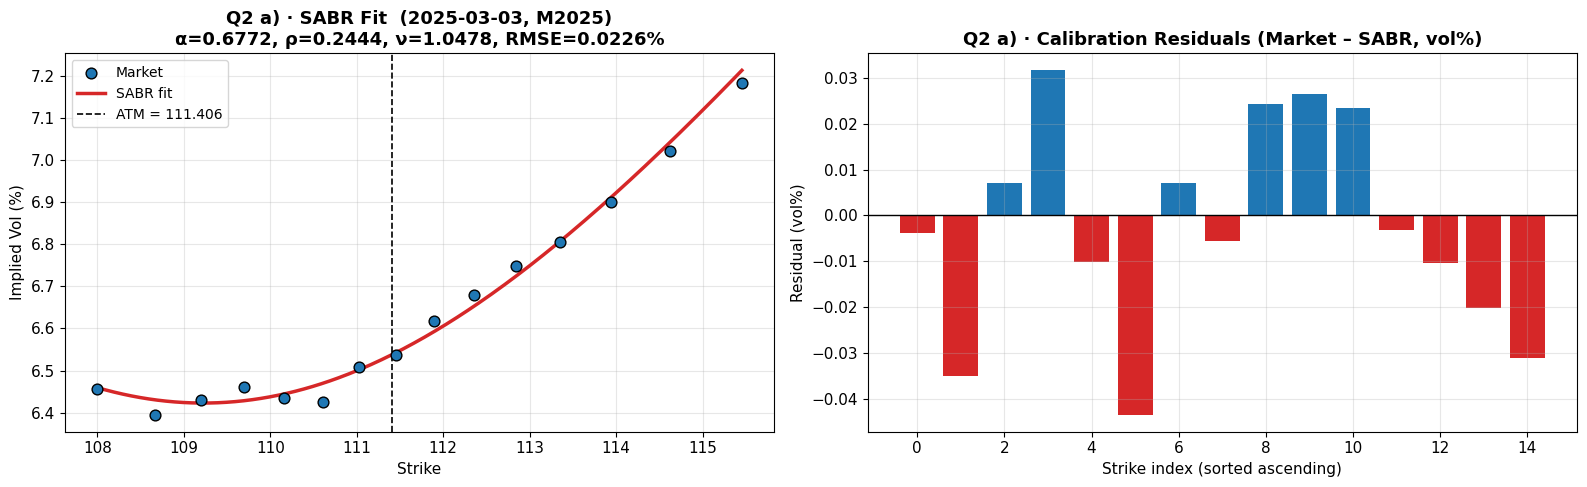

In [11]:
q2a_calib = calibrate_sabr(q1a_smile)

# Parameter table 
display(pd.DataFrame([{
    "Date": q1a_date.date(), "Contract": "M2025",
    "α (alpha)": round(q2a_calib["alpha"], 6),
    "β (beta)":  round(q2a_calib["beta"],  2),
    "ρ (rho)":   round(q2a_calib["rho"],   6),
    "ν (nu)":    round(q2a_calib["nu"],    6),
    "σ_ATM (%)": round(q2a_calib["sigma_atm"] * 100, 4),
    "RMSE (vol%)": round(q2a_calib["rmse"] * 100, 5),
    "Success":   q2a_calib["success"],
}]).style.set_caption("Q2 a) · SABR Parameters – Representative Date"))

# Overlay plot 
K_grid = np.linspace(q2a_calib["strikes"].min(),
                      q2a_calib["strikes"].max(), 300)
sigma_grid = np.array([
    sabr_implied_vol(q1a_F, k, q1a_row["Expiration Option"],
                     q2a_calib["alpha"], BETA, q2a_calib["rho"], q2a_calib["nu"])
    for k in K_grid
])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.scatter(q2a_calib["strikes"], q2a_calib["vols"] * 100,
           s=60, color="#1f77b4", edgecolors="black", zorder=4, label="Market")
ax.plot(K_grid, sigma_grid * 100, "-", color="#d62728", lw=2.5, label="SABR fit")
ax.axvline(q1a_F, color="black", ls="--", lw=1.2, label=f"ATM = {q1a_F:.3f}")
ax.set_title(f"Q2 a) · SABR Fit  ({q1a_date.date()}, M2025)\n"
             f"α={q2a_calib['alpha']:.4f}, ρ={q2a_calib['rho']:.4f}, "
             f"ν={q2a_calib['nu']:.4f}, RMSE={q2a_calib['rmse']*100:.4f}%")
ax.set_xlabel("Strike"); ax.set_ylabel("Implied Vol (%)"); ax.legend()

ax = axes[1]
resid = (q2a_calib["vols"] - q2a_calib["fitted"]) * 100
ax.bar(range(len(resid)), resid, color=["#d62728" if r < 0 else "#1f77b4" for r in resid])
ax.axhline(0, color="black", lw=1)
ax.set_title("Q2 a) · Calibration Residuals (Market – SABR, vol%)")
ax.set_xlabel("Strike index (sorted ascending)"); ax.set_ylabel("Residual (vol%)")

fig.tight_layout(); plt.show()

### SABR calibrates to ATM. Why is there a difference here.

### Q2. b) & Q2. c) – Daily SABR Calibration: All Contracts

We calibrate SABR for every trading day in M2025, H2026, and M2026, record (α, ρ, ν, σ<sub>ATM</sub>, RMSE), and report time-series plots plus
summary statistics per contract.

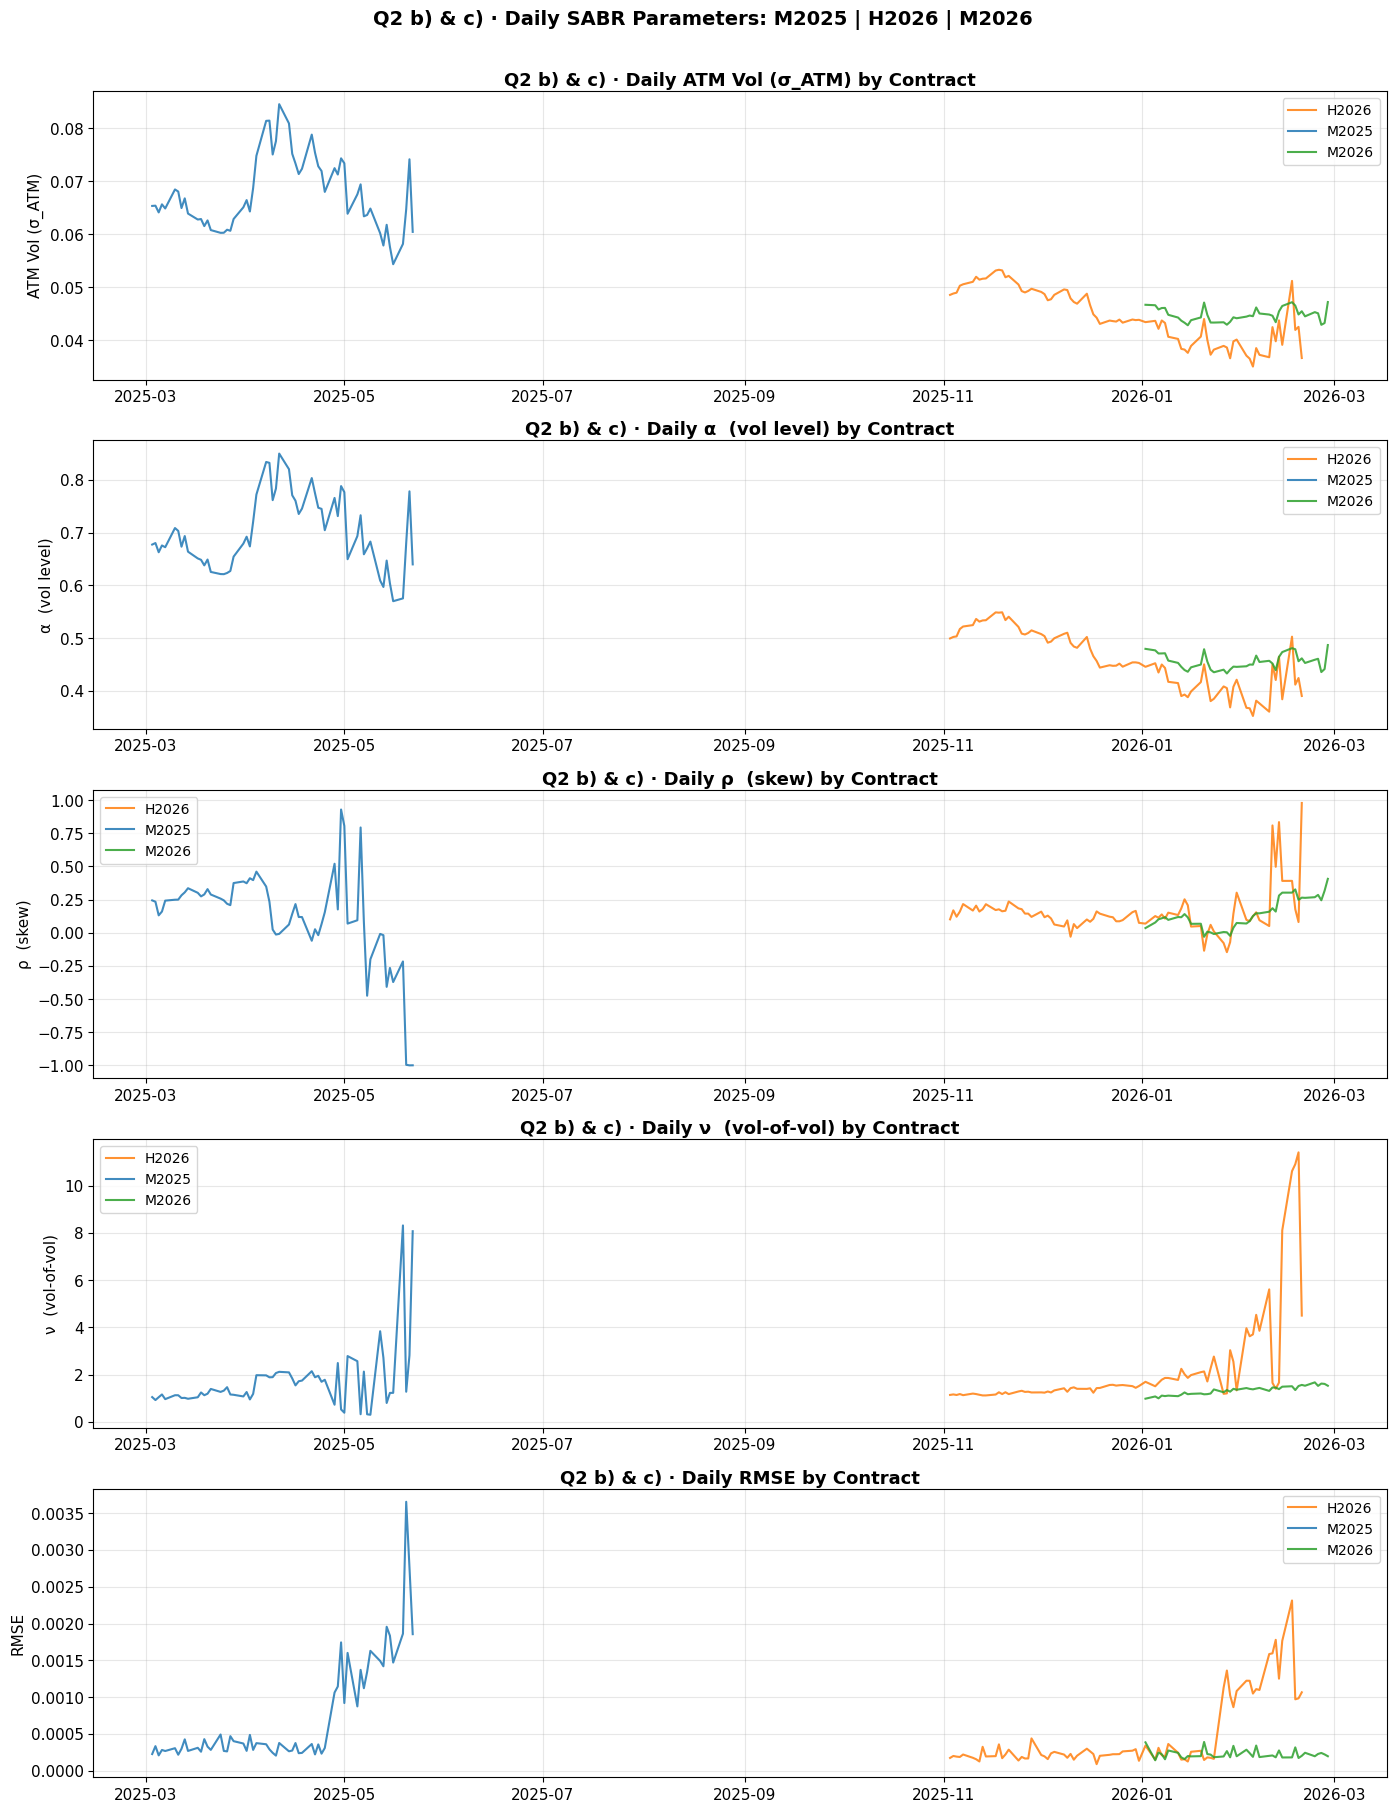

,date,contract,alpha,rho,nu,rmse_bp,sigma_atm_pct
134,2025-05-20 00:00:00,M2025,0.680265,-0.995674,1.275231,36.539183,6.475750
135,2025-05-21 00:00:00,M2025,0.777956,-0.999857,2.816388,27.644241,7.418400
74,2026-02-16 00:00:00,H2026,0.502795,0.391462,10.615497,23.126495,5.121900
130,2025-05-14 00:00:00,M2025,0.646844,-0.407702,0.798671,19.558249,6.181150
133,2025-05-19 00:00:00,M2025,0.575297,-0.216224,8.316801,18.611756,5.819850
136,2025-05-22 00:00:00,M2025,0.639658,-0.999397,8.071225,18.551459,6.047700
131,2025-05-15 00:00:00,M2025,0.603900,-0.265043,1.225017,18.343938,5.765600
71,2026-02-11 00:00:00,H2026,0.420745,0.497662,1.401925,17.782133,3.981350
73,2026-02-13 00:00:00,H2026,0.384290,0.391347,8.109630,17.647848,3.914600
120,2025-04-30 00:00:00,M2025,0.787885,0.929574,0.526291,17.434509,7.436500


In [12]:
def calibrate_contract(df_surface, beta=BETA):
    """Run daily SABR calibration for one contract surface DataFrame."""
    results = []
    for _, row in df_surface.sort_values("date").iterrows():
        smile  = build_smile(row)
        calib  = calibrate_sabr(smile, beta=beta)
        results.append({
            "date":      row["date"],
            "contract":  row.get("contract", ""),
            "F":         float(row["Future Price"]),
            "T":         float(row["Expiration Option"]),
            "sigma_atm": calib["sigma_atm"],
            "alpha":     calib["alpha"],
            "beta":      calib["beta"],
            "rho":       calib["rho"],
            "nu":        calib["nu"],
            "rmse":      calib["rmse"],
            "success":   calib["success"],
        })
    return pd.DataFrame(results)


# Calibrate M2025
sabr_M2025 = calibrate_contract(ty_option_surfaces_M2025)

# Calibrate H2026
sabr_H2026 = calibrate_contract(ty_option_surfaces_H2026)

# Calibrate M2026
sabr_M2026 = calibrate_contract(ty_option_surfaces_M2026)

# Combine all contracts
sabr_all = (pd.concat([sabr_M2025, sabr_H2026, sabr_M2026], ignore_index=True)
              .sort_values(["contract", "date"]).reset_index(drop=True))


# Display summary statistics
summary = (sabr_all.groupby("contract")[["sigma_atm", "alpha", "rho", "nu", "rmse"]]
           .agg(["mean", "std", "min", "max"]).round(6))
display(summary.style.set_caption("Q2 b) · SABR Parameter Summary Statistics by Contract"))


# Time-series plots
CMAP = {"M2025": "#1f77b4", "H2026": "#ff7f0e", "M2026": "#2ca02c"}
param_labels = {
    "sigma_atm": "ATM Vol (σ_ATM)",
    "alpha": "α  (vol level)",
    "rho":   "ρ  (skew)",
    "nu":    "ν  (vol-of-vol)",
    "rmse":  "RMSE",
}

fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=False)
for ax, (param, plabel) in zip(axes, param_labels.items()):
    for contract, grp in sabr_all.groupby("contract"):
        ax.plot(grp["date"], grp[param], color=CMAP[contract],
                lw=1.5, alpha=0.85, label=contract)
    ax.set_ylabel(plabel)
    ax.set_title(f"Q2 b) & c) · Daily {plabel} by Contract", pad=4)
    ax.legend(loc="best")

fig.suptitle("Q2 b) & c) · Daily SABR Parameters: M2025 | H2026 | M2026",
             fontsize=14, fontweight="bold", y=1.005)
fig.tight_layout(); plt.show()


# Worst-fit dates
worst = (sabr_all.nlargest(10, "rmse")
         [["date", "contract", "sigma_atm", "rmse", "alpha", "rho", "nu"]]
         .assign(rmse_bp=lambda d: d["rmse"] * 10_000,
                 sigma_atm_pct=lambda d: d["sigma_atm"] * 100)
         .drop(columns=["rmse", "sigma_atm"]))
display(worst.style.set_caption("Q2 c) · 10 Worst Calibration Days (highest RMSE)"))

### lets show a plot of the worst fit

## Question 3 – Calibration Quality and Regime Identification

We now analyse *when* and *why* SABR fits well or poorly, and identify
structurally distinct regimes from the daily calibration results.

### Q3. a) – Daily RMSE vs. ATM Volatility

If SABR systematically fails during volatile periods, we should see positive
correlation between ATM vol and RMSE (higher vol → worse fit).

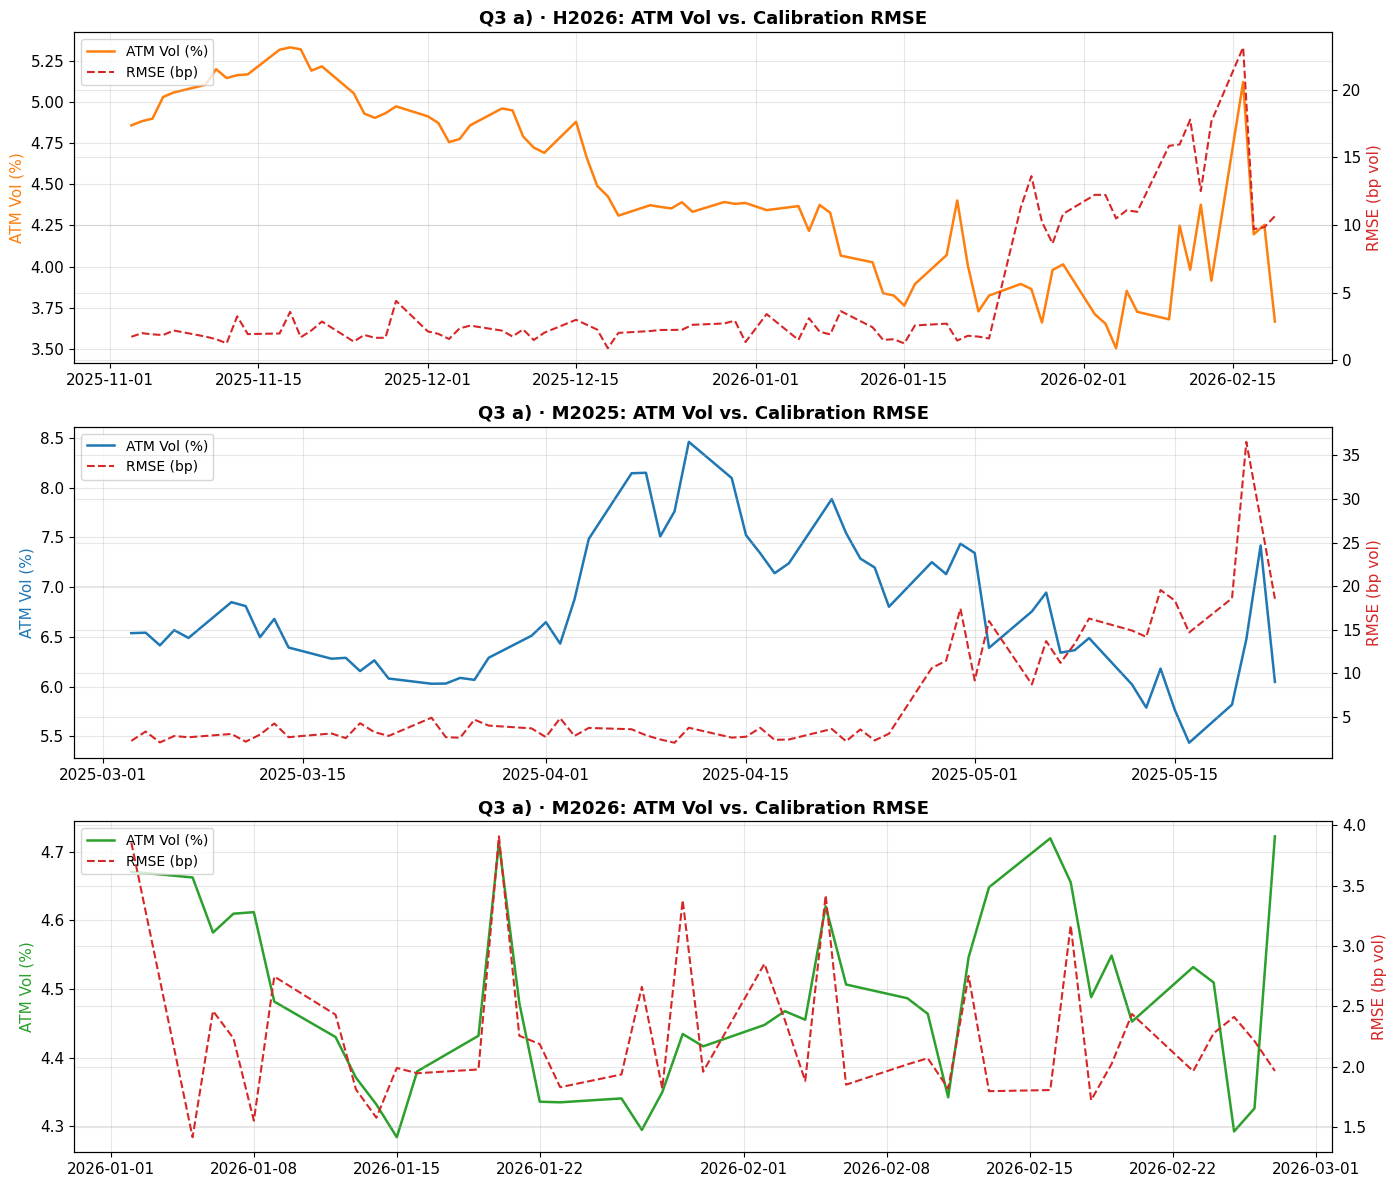

,Pearson r,p-value
Contract,,
H2026,-0.440300,0.0001
M2025,-0.262900,0.0442
M2026,0.276100,0.0806


In [13]:
fig, axes = plt.subplots(len(CMAP), 1, figsize=(14, 12), sharex=False)
corr_records = []

for ax, (contract, grp) in zip(axes, sabr_all.groupby("contract")):
    grp = grp.sort_values("date")
    ax2 = ax.twinx()
    l1, = ax.plot(grp["date"], grp["sigma_atm"] * 100,
                  color=CMAP[contract], lw=1.8, label="ATM Vol (%)")
    l2, = ax2.plot(grp["date"], grp["rmse"] * 10_000,
                   color="#d62728", lw=1.5, ls="--", label="RMSE (bp)")
    ax.set_ylabel("ATM Vol (%)", color=CMAP[contract])
    ax2.set_ylabel("RMSE (bp vol)", color="#d62728")
    ax.set_title(f"Q3 a) · {contract}: ATM Vol vs. Calibration RMSE")
    ax.legend(handles=[l1, l2], loc="upper left")

    valid = grp[["sigma_atm", "rmse"]].dropna()
    r, p = pearsonr(valid["sigma_atm"], valid["rmse"])
    corr_records.append({"Contract": contract, "Pearson r": round(r, 4),
                         "p-value": f"{p:.4f}"})

fig.tight_layout(); plt.show()

display(pd.DataFrame(corr_records).set_index("Contract")
        .style.set_caption("Q3 a) · Pearson Correlation: ATM Vol vs. RMSE"))

### Checking level right now. we should look at trend 

### Q3. b) – Largest Day-over-Day SABR Parameter Shifts

Metric: |Δν| + |Δρ| is computed contract-by-contract.

We rank all days globally, display the top 5, and show pre/post smiles for
the three largest events.

,date,contract,alpha,rho,nu,d_nu,d_rho,change_score,sigma_atm_pct,rmse_bp
0,2025-05-20 00:00:00,M2025,0.680265,-0.995674,1.275231,-7.041570,-0.779451,7.821020,6.475750,36.539183
1,2026-02-19 00:00:00,H2026,0.390555,0.978977,4.498999,-6.910848,0.897793,7.808641,3.665800,10.651418
2,2025-05-19 00:00:00,M2025,0.575297,-0.216224,8.316801,7.089165,0.155387,7.244552,5.819850,18.611756
3,2026-02-13 00:00:00,H2026,0.384290,0.391347,8.109630,6.447053,-0.443412,6.890465,3.914600,17.647848
4,2025-05-22 00:00:00,M2025,0.639658,-0.999397,8.071225,5.254837,0.000460,5.255297,6.047700,18.551459


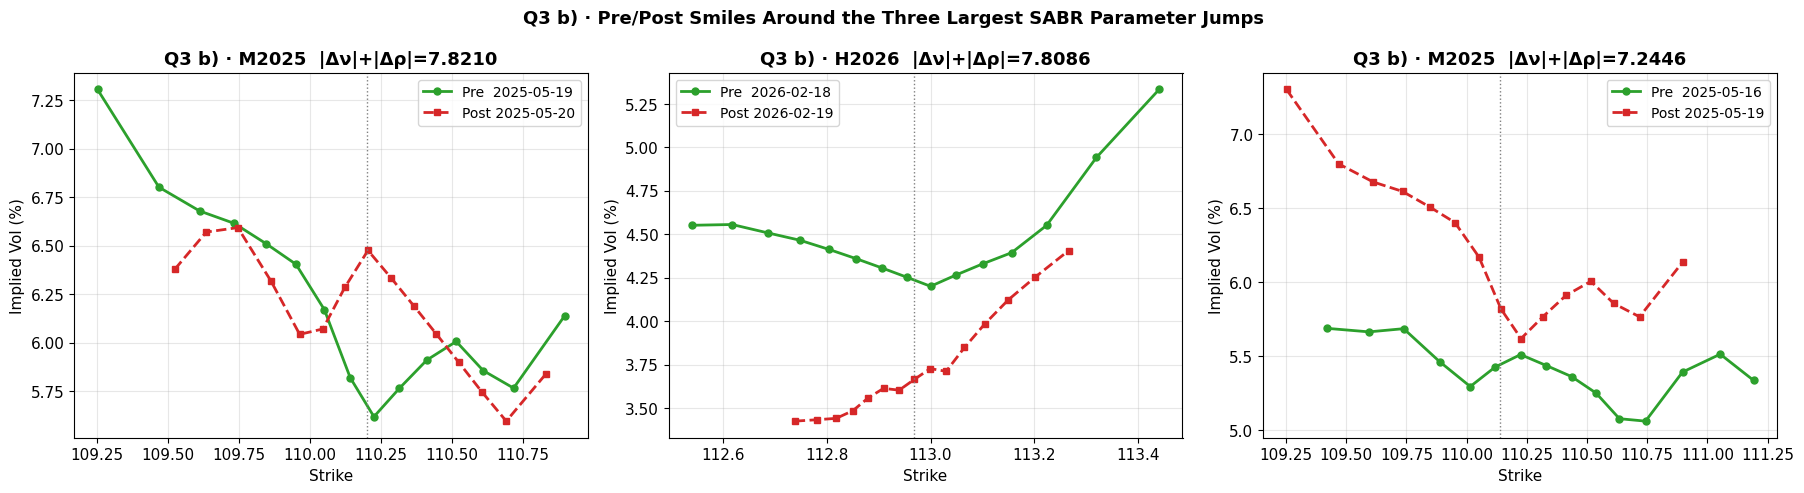

In [14]:
sabr_all = sabr_all.sort_values(["contract", "date"]).copy()
sabr_all["d_nu"]  = sabr_all.groupby("contract")["nu"].diff()
sabr_all["d_rho"] = sabr_all.groupby("contract")["rho"].diff()
sabr_all["change_score"] = sabr_all["d_nu"].abs() + sabr_all["d_rho"].abs()

top5 = (sabr_all.dropna(subset=["change_score"])
        .nlargest(5, "change_score")
        [["date", "contract", "sigma_atm", "alpha", "rho", "nu",
          "d_nu", "d_rho", "change_score", "rmse"]]
        .reset_index(drop=True))

display(top5.assign(
    sigma_atm_pct=lambda d: d["sigma_atm"] * 100,
    rmse_bp=lambda d: d["rmse"] * 10_000,
).drop(columns=["sigma_atm", "rmse"])
.style.set_caption("Q3 b) · Top 5 Dates by Largest Day-over-Day SABR Parameter Change (|Δν| + |Δρ|)"))


# Pre / post smile plots for top 3 events
CONTRACT_DF = {
    "M2025": ty_option_surfaces_M2025,
    "H2026": ty_option_surfaces_H2026,
    "M2026": ty_option_surfaces_M2026,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (_, ev) in enumerate(top5.head(3).iterrows()):
    contract = ev["contract"]
    dt       = ev["date"]
    df_c     = CONTRACT_DF[contract].sort_values("date").reset_index(drop=True)
    pos      = df_c.index[df_c["date"] == dt].tolist()
    if not pos or pos[0] == 0:
        axes[idx].text(0.5, 0.5, "No pre-date available", ha="center", va="center")
        continue

    pre_row  = df_c.iloc[pos[0] - 1]
    post_row = df_c.iloc[pos[0]]
    pre_smile  = build_smile(pre_row)
    post_smile = build_smile(post_row)

    ax = axes[idx]
    ax.plot(pre_smile["strike"],  pre_smile["vol"]  * 100, "o-",
            color="#2ca02c", lw=2, ms=5, label=f"Pre  {pre_row['date'].date()}")
    ax.plot(post_smile["strike"], post_smile["vol"] * 100, "s--",
            color="#d62728", lw=2, ms=5, label=f"Post {post_row['date'].date()}")
    ax.axvline(post_row["Future Price"], color="grey", ls=":", lw=1)
    ax.set_title(f"Q3 b) · {contract}  |Δν|+|Δρ|={ev['change_score']:.4f}")
    ax.set_xlabel("Strike"); ax.set_ylabel("Implied Vol (%)"); ax.legend()

fig.suptitle("Q3 b) · Pre/Post Smiles Around the Three Largest SABR Parameter Jumps",
             fontsize=13, fontweight="bold")
fig.tight_layout(); plt.show()

### Q3. c) – Term-Structure of SABR Parameters: H2026 vs. M2026

Both contracts are actively quoted during January–February 2026 but expire at
different times. Comparing same-calendar-day
SABR parameters isolates the effect of **time-to-expiry** on smile shape.

,Overlap Start,Overlap End,Num Days
0,2026-01-02,2026-02-19,35


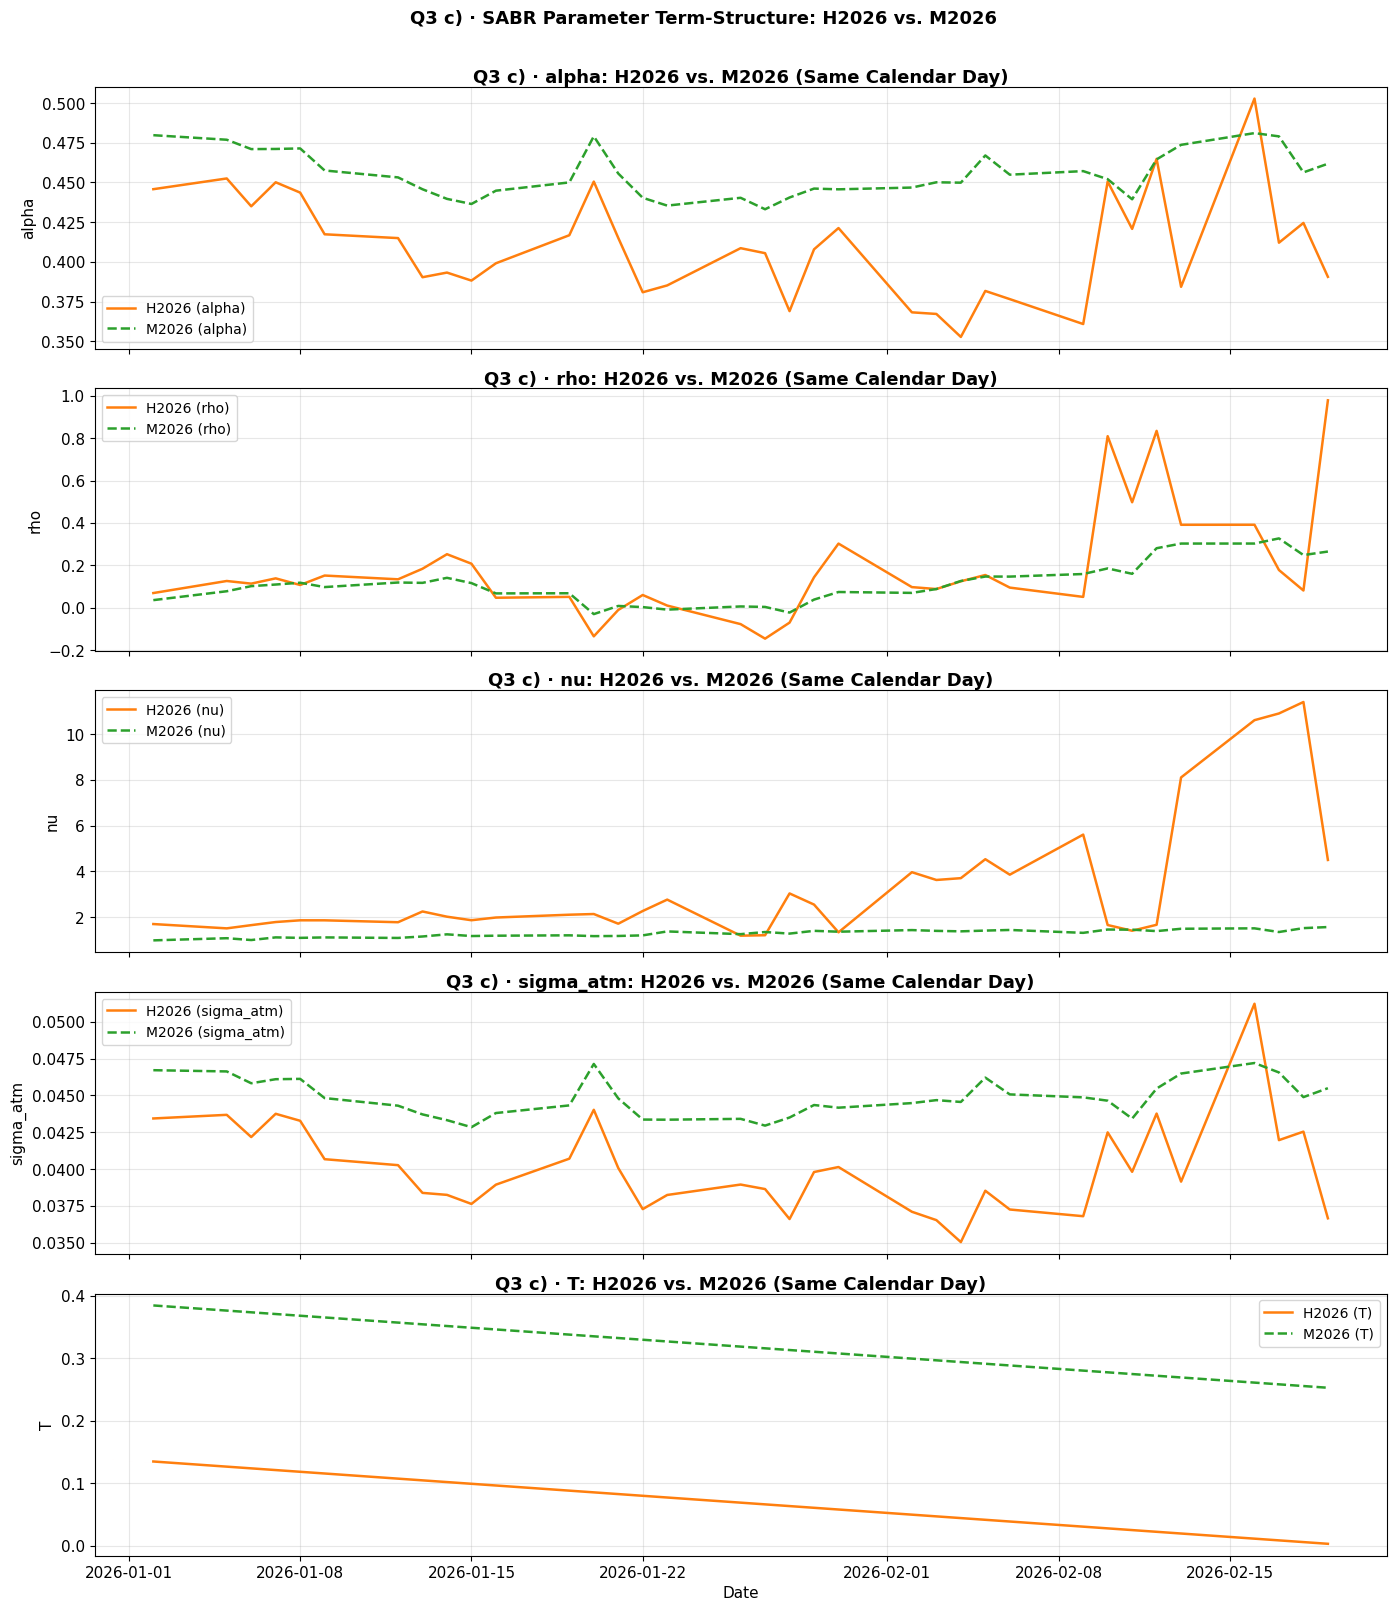

,Mean H2026,Mean M2026,Mean Diff (H–M)
Parameter,,,
α,0.409943,0.455629,-0.045685
ρ,0.183725,0.115638,0.068087
ν,3.315846,1.286195,2.029651
σ_ATM,0.040108,0.044842,-0.004734
T (yrs),0.067425,0.316740,-0.249315


In [15]:
overlap = (sabr_H2026.merge(sabr_M2026, on="date", suffixes=("_H2026", "_M2026"))
           .sort_values("date"))

overlap_info = pd.DataFrame({
    "Overlap Start": [overlap['date'].min().date()],
    "Overlap End": [overlap['date'].max().date()],
    "Num Days": [len(overlap)],
})
display(overlap_info.style.set_caption("Q3 c) · Overlap Window: H2026 vs. M2026"))


# Time-series comparison
params_ov = ["alpha", "rho", "nu", "sigma_atm", "T"]
fig, axes = plt.subplots(len(params_ov), 1, figsize=(14, 16), sharex=True)
for ax, p in zip(axes, params_ov):
    ax.plot(overlap["date"], overlap[f"{p}_H2026"],
            color="#ff7f0e", lw=1.8, label=f"H2026 ({p})")
    ax.plot(overlap["date"], overlap[f"{p}_M2026"],
            color="#2ca02c", lw=1.8, ls="--", label=f"M2026 ({p})")
    ax.set_ylabel(p); ax.legend()
    ax.set_title(f"Q3 c) · {p}: H2026 vs. M2026 (Same Calendar Day)", pad=3)
axes[-1].set_xlabel("Date")
fig.suptitle("Q3 c) · SABR Parameter Term-Structure: H2026 vs. M2026",
             fontsize=13, fontweight="bold", y=1.005)
fig.tight_layout(); plt.show()


# Summary statistics of differences
diff_stats = pd.DataFrame({
    "Parameter": ["α", "ρ", "ν", "σ_ATM", "T (yrs)"],
    "Mean H2026": [overlap[f"{p}_H2026"].mean()
                   for p in ["alpha","rho","nu","sigma_atm","T"]],
    "Mean M2026": [overlap[f"{p}_M2026"].mean()
                   for p in ["alpha","rho","nu","sigma_atm","T"]],
    "Mean Diff (H–M)": [(overlap[f"{p}_H2026"] - overlap[f"{p}_M2026"]).mean()
                         for p in ["alpha","rho","nu","sigma_atm","T"]],
}).round(6)
display(diff_stats.set_index("Parameter")
        .style.set_caption("Q3 c) · Average SABR Parameters: H2026 vs. M2026 Overlap"))

### Q3. d) – Lazy Recalibration: Stale (ν, ρ), Updated α Only

We test holding (ν, ρ) fixed at their values from N = 5, 10, 20 days ago,
updating only α each day through the ATM constraint. The RMSE uplift versus
daily full recalibration measures how quickly stale parameters degrade fit quality.

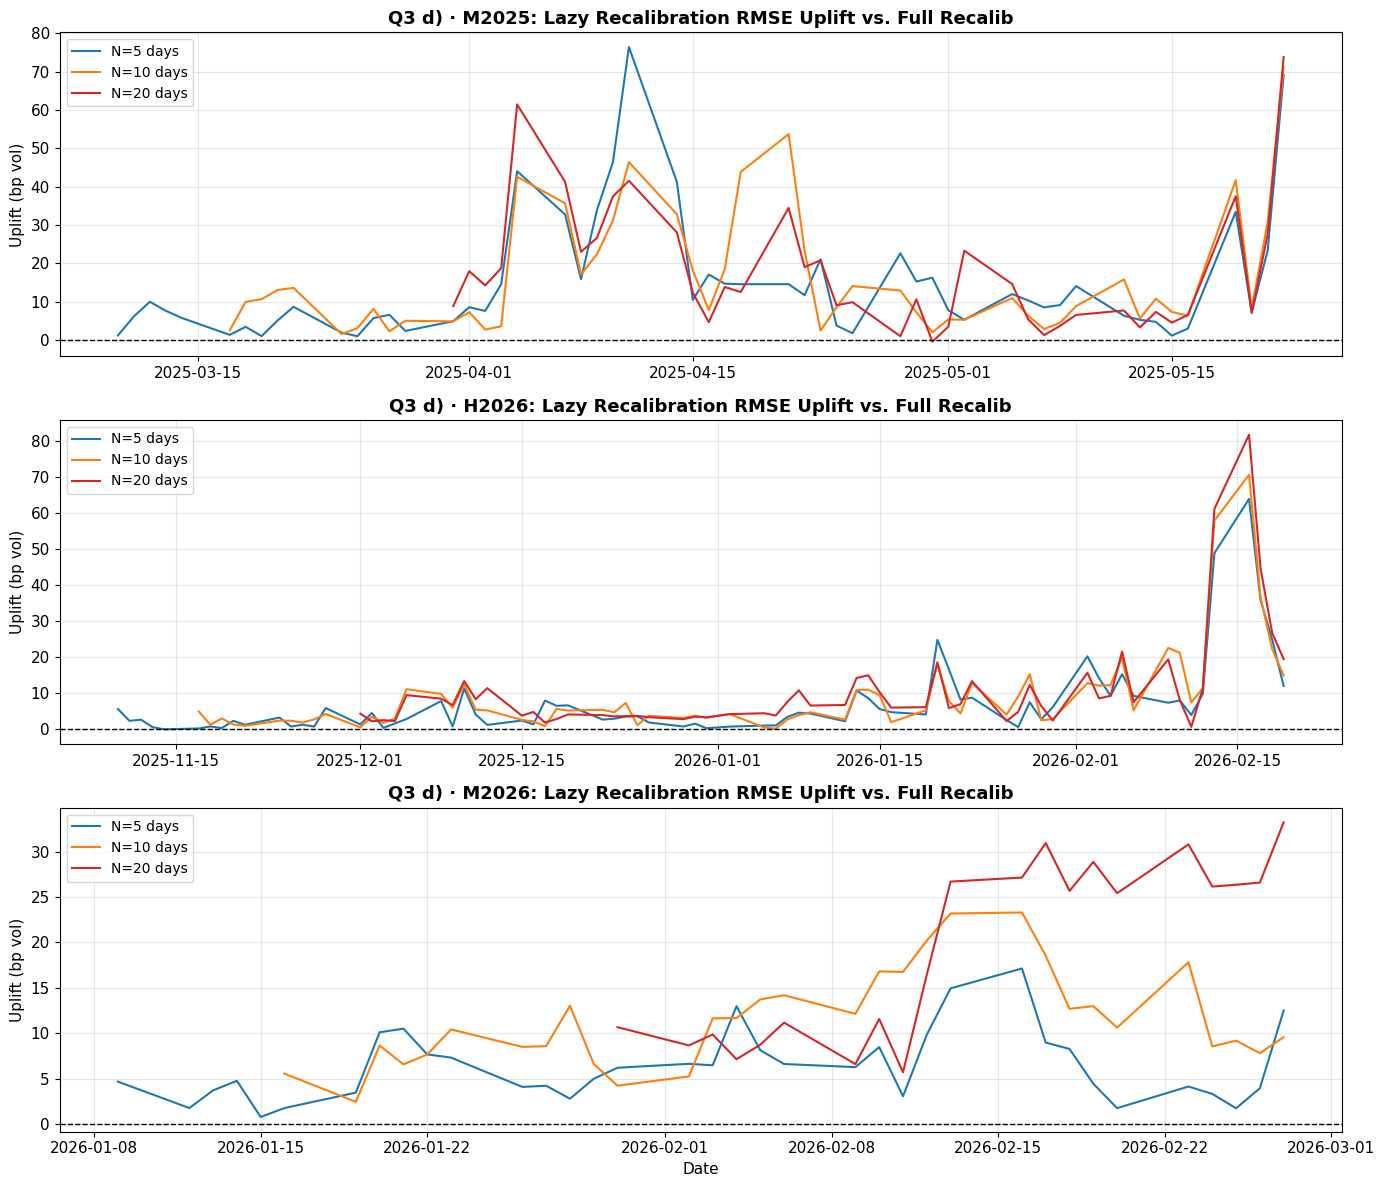

In [16]:
def lazy_rmse(df_surface, sabr_calib_df, stale_days, beta=BETA):
    """
    Compute lazy-recalibration RMSE: use (ν, ρ) from `stale_days` ago,
    update α via ATM constraint each day.
    """
    df_s  = df_surface.sort_values("date").reset_index(drop=True)
    cal_s = sabr_calib_df.sort_values("date").reset_index(drop=True)

    records = []
    for i in range(stale_days, len(df_s)):
        row       = df_s.iloc[i]
        stale_row = cal_s.iloc[i - stale_days]

        nu_stale  = float(stale_row["nu"])
        rho_stale = float(stale_row["rho"])
        if not (np.isfinite(nu_stale) and np.isfinite(rho_stale)):
            continue

        smile      = build_smile(row)
        sub        = smile.dropna(subset=["strike","vol"])
        strikes    = sub["strike"].to_numpy()
        mkt_vols   = sub["vol"].to_numpy()
        F          = float(row["Future Price"])
        T          = float(row["Expiration Option"])
        sigma_atm  = float(np.interp(F, strikes, mkt_vols))

        alpha_lazy = solve_alpha(sigma_atm, F, T, beta, rho_stale, nu_stale)
        if not np.isfinite(alpha_lazy):
            continue

        fitted_lazy = np.array([
            sabr_implied_vol(F, k, T, alpha_lazy, beta, rho_stale, nu_stale)
            for k in strikes])
        rmse_lazy = np.sqrt(np.mean((fitted_lazy - mkt_vols)**2))

        records.append({
            "date":      row["date"],
            "contract":  row.get("contract",""),
            "stale_days": stale_days,
            "rmse_lazy": rmse_lazy,
        })
    return pd.DataFrame(records)


# Run for all contracts and stale horizons
lazy_records = []
for N in [5, 10, 20]:
    for df_s, cal_s in [(ty_option_surfaces_M2025, sabr_M2025),
                         (ty_option_surfaces_H2026, sabr_H2026),
                         (ty_option_surfaces_M2026, sabr_M2026)]:
        lazy_records.append(lazy_rmse(df_s, cal_s, N))

lazy_df = pd.concat(lazy_records, ignore_index=True)

# Merge with full-recalibration RMSE
lazy_merged = lazy_df.merge(
    sabr_all[["date","contract","rmse"]].rename(columns={"rmse":"rmse_full"}),
    on=["date","contract"], how="left"
)
lazy_merged["rmse_uplift"] = lazy_merged["rmse_lazy"] - lazy_merged["rmse_full"]


# Summary table
lazy_summary = (lazy_merged.groupby(["contract","stale_days"])
                [["rmse_full","rmse_lazy","rmse_uplift"]]
                .mean() * 10_000).round(3)
lazy_summary.columns = ["Full Recalib RMSE (bp)", "Lazy RMSE (bp)", "Uplift (bp)"]
display(lazy_summary.style.set_caption(
    "Q3 d) · Average RMSE: Full vs. Lazy Recalibration (bp vol)"))


# RMSE uplift time series
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)
for ax, contract in zip(axes, ["M2025","H2026","M2026"]):
    sub = lazy_merged[lazy_merged["contract"] == contract]
    for N, col in zip([5,10,20], ["#1f77b4","#ff7f0e","#d62728"]):
        g = sub[sub["stale_days"] == N]
        ax.plot(g["date"], g["rmse_uplift"] * 10_000,
                color=col, lw=1.5, label=f"N={N} days")
    ax.axhline(0, color="black", ls="--", lw=1)
    ax.set_title(f"Q3 d) · {contract}: Lazy Recalibration RMSE Uplift vs. Full Recalib")
    ax.set_ylabel("Uplift (bp vol)"); ax.legend()
axes[-1].set_xlabel("Date")
fig.tight_layout(); plt.show()

### Lock in a value and show how RMSE evolves

## Question 4 – Listed vs. OTC: Cross-Product SABR Comparison (April 2025)

The `swaption_smile_daily_2025.xlsx` data covers April 2025 in the 1Yx5Y swaption market. This is the only window where both products overlap. We calibrate SABR (β=0.5) to the swaption smiles and compare dynamics with TY M2025.

**Swaption data conventions**:
- Black vol columns: moneyness in bp (–300, –200, … +300), vols in %
- ATM forward: `atm_fwd_pct` in %
- Absolute strikes: `absolute_strikes_pct` in %
- T = 1 year (1Y option expiry in 1Yx5Y)

### Q4. a) – Calibrate swaption smiles

,date,F,T,alpha,beta,rho,nu,sigma_atm,rmse,success
0,2025-04-01 00:00:00,0.035700,1.000000,0.055371,0.500000,-0.304705,0.753993,0.302800,0.010337,True
1,2025-04-02 00:00:00,0.035200,1.000000,0.055465,0.500000,-0.329124,0.774911,0.305500,0.011990,True
2,2025-04-03 00:00:00,0.033500,1.000000,0.058379,0.500000,-0.359516,0.834442,0.330400,0.018436,True
3,2025-04-04 00:00:00,0.033100,1.000000,0.059994,0.500000,-0.361321,0.846209,0.341800,0.020133,True
4,2025-04-07 00:00:00,0.034600,1.000000,0.060829,0.500000,-0.350302,0.804206,0.338000,0.014251,True
5,2025-04-08 00:00:00,0.034700,1.000000,0.060665,0.500000,-0.334754,0.799259,0.336900,0.014066,True
6,2025-04-09 00:00:00,0.036400,1.000000,0.056874,0.500000,-0.254189,0.734322,0.308400,0.009068,True
7,2025-04-10 00:00:00,0.036700,1.000000,0.057815,0.500000,-0.249778,0.728326,0.312100,0.008404,True
8,2025-04-11 00:00:00,0.037600,1.000000,0.057853,0.500000,-0.244705,0.719987,0.308400,0.007410,True
9,2025-04-14 00:00:00,0.036500,1.000000,0.057815,0.500000,-0.257371,0.734568,0.313000,0.009228,True


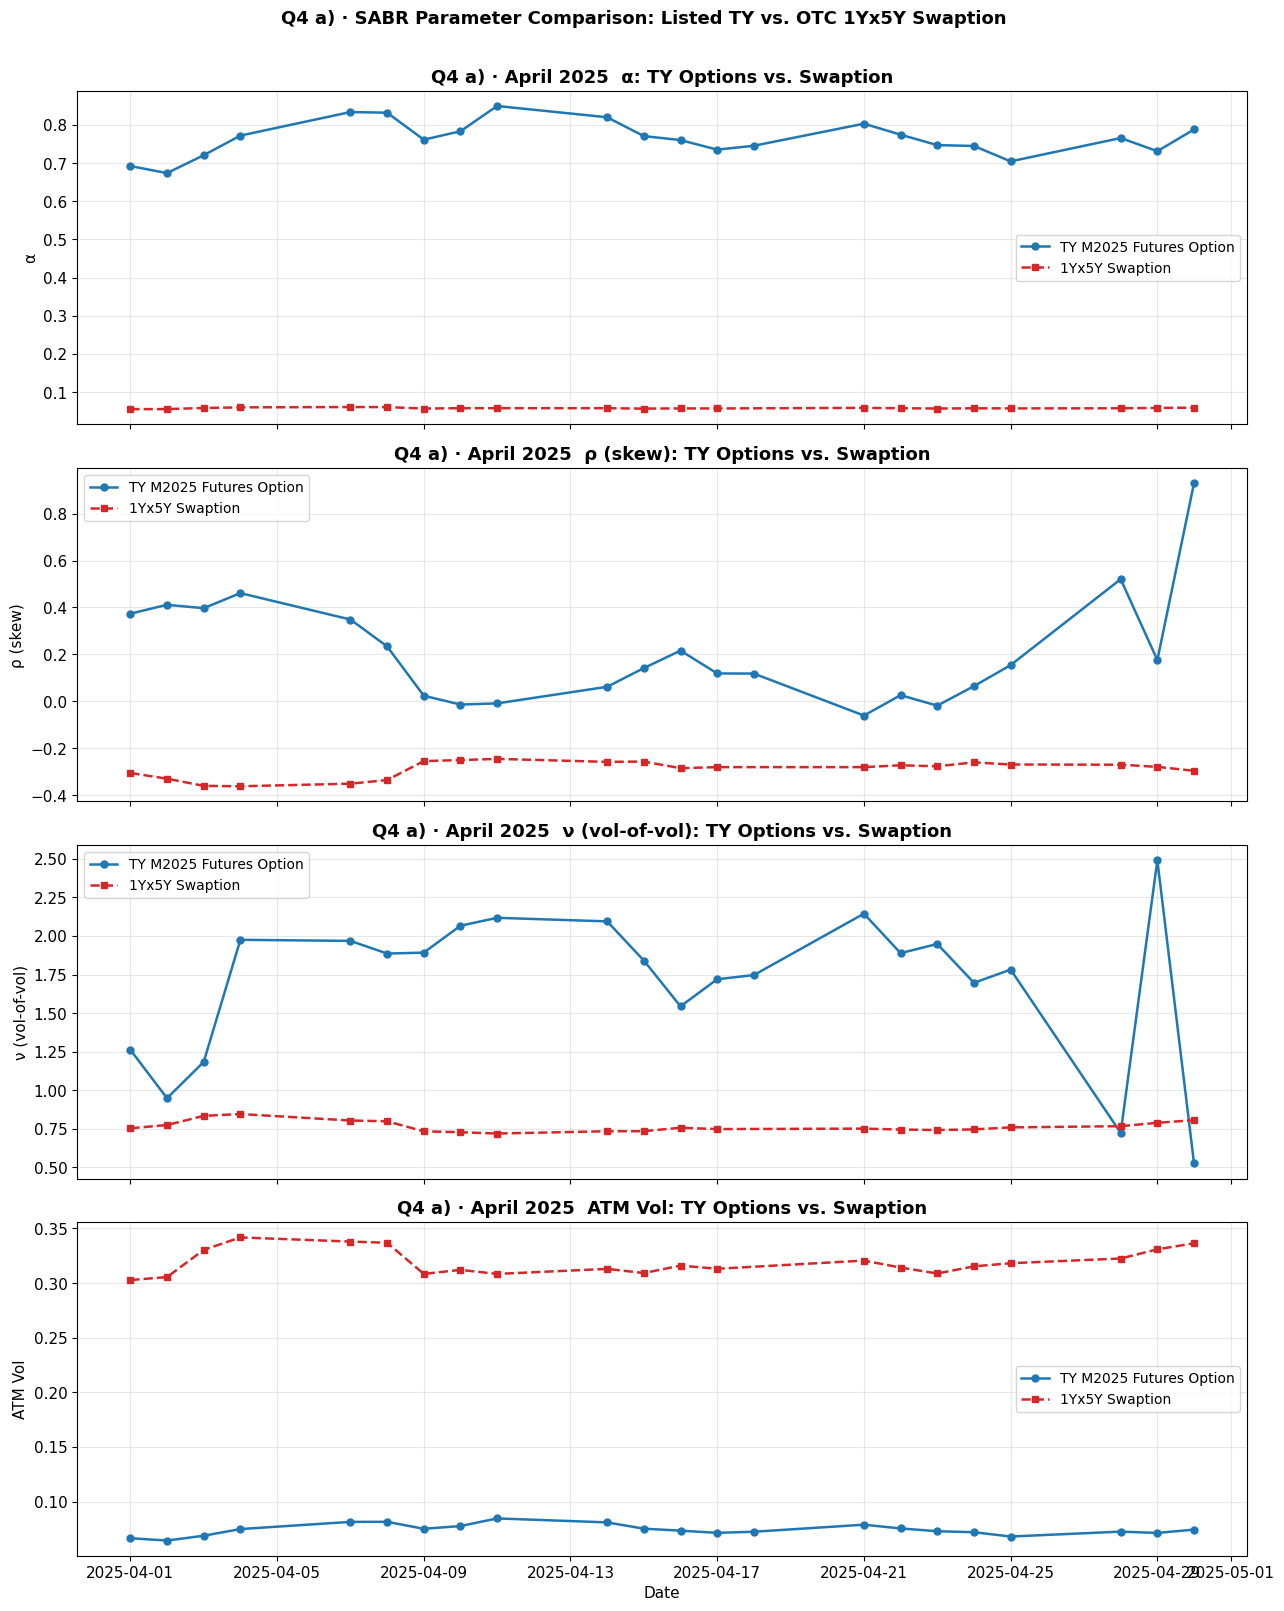

In [17]:
def calibrate_swaptions(beta=BETA):
    """SABR calibration for each day of the 1Yx5Y swaption smile."""
    sw_mono_cols = [c for c in swaption_smile_black_vol_pct.columns if c != "date"]
    T_sw = 1.0
    records = []

    for dt in swaption_smile_black_vol_pct["date"].sort_values():
        vol_row  = swaption_smile_black_vol_pct[swaption_smile_black_vol_pct["date"] == dt].iloc[0]
        fwd_row  = swaption_smile_atm_forward  [swaption_smile_atm_forward  ["date"] == dt].iloc[0]
        strk_row = swaption_smile_abs_strike_pct[swaption_smile_abs_strike_pct["date"] == dt].iloc[0]

        F       = float(fwd_row["atm_fwd_pct"]) / 100.0
        strikes = np.array([float(strk_row[c]) / 100.0 for c in sw_mono_cols])
        vols    = np.array([float(vol_row[c])  / 100.0 for c in sw_mono_cols])

        # Build pseudo smile_df compatible with calibrate_sabr
        smile_sw = pd.DataFrame({
            "strike":       strikes, "vol": vols,
            "Future_Price": F, "T": T_sw,
        })
        calib = calibrate_sabr(smile_sw, beta=beta)

        records.append({
            "date": dt, "F": F, "T": T_sw,
            "alpha": calib["alpha"], "beta": calib["beta"],
            "rho":   calib["rho"],   "nu":   calib["nu"],
            "sigma_atm": calib["sigma_atm"], "rmse": calib["rmse"],
            "success": calib["success"],
        })
    return pd.DataFrame(records)


# Calibrate swaption smiles
sabr_sw = calibrate_swaptions()
display(sabr_sw.style.set_caption("Q4 a) · Swaption SABR Calibration Results (April 2025)"))


# TY M2025 sub-sample for April 2025
ty_apr = (sabr_M2025[
    (sabr_M2025["date"] >= pd.Timestamp("2025-04-01")) &
    (sabr_M2025["date"] <= pd.Timestamp("2025-04-30"))
].copy())


# Time-series overlay
fig, axes = plt.subplots(4, 1, figsize=(13, 16), sharex=True)
params_4 = [("alpha","α"), ("rho","ρ (skew)"), ("nu","ν (vol-of-vol)"),
            ("sigma_atm","ATM Vol")]

for ax, (p, plabel) in zip(axes, params_4):
    ax.plot(ty_apr["date"], ty_apr[p], "o-", color="#1f77b4", lw=1.8, ms=5,
            label="TY M2025 Futures Option")
    ax.plot(sabr_sw["date"], sabr_sw[p], "s--", color="#d62728", lw=1.8, ms=5,
            label="1Yx5Y Swaption")
    ax.set_ylabel(plabel); ax.legend()
    ax.set_title(f"Q4 a) · April 2025  {plabel}: TY Options vs. Swaption")

axes[-1].set_xlabel("Date")
fig.suptitle("Q4 a) · SABR Parameter Comparison: Listed TY vs. OTC 1Yx5Y Swaption",
             fontsize=13, fontweight="bold", y=1.005)
fig.tight_layout(); plt.show()

### Look into scaling

### Q4. b) – Cross-Market Agreement on Large-Move Dates

On the dates identified in Q3b as having the largest TY parameter jumps,
we compare the direction and magnitude of (ν, ρ) changes for swaptions.

,Δν TY,Δρ TY,Score (TY),Δν Swaption,Δρ Swaption
date,,,,,
2025-04-30 00:00:00,-1.963900,0.753560,2.717460,0.016950,-0.016670
2025-04-29 00:00:00,1.765860,-0.344580,2.110440,0.021980,-0.009240
2025-04-28 00:00:00,-1.057710,0.365920,1.423640,0.007650,-0.000870
2025-04-04 00:00:00,0.791430,0.064190,0.855630,0.011770,-0.001800
2025-04-21 00:00:00,0.397740,-0.178750,0.576480,0.002890,-0.000120


,Δν TY,Δρ TY,Score (TY),Δν Swaption,Δρ Swaption,ν agree direction?,ρ agree direction?,ν |SW/TY| ratio,ρ |SW/TY| ratio
date,,,,,,,,,
2025-04-30 00:00:00,-1.963900,0.753560,2.717460,0.016950,-0.016670,✗ No,✗ No,0.009000,0.022000
2025-04-29 00:00:00,1.765860,-0.344580,2.110440,0.021980,-0.009240,✓ Yes,✓ Yes,0.012000,0.027000
2025-04-28 00:00:00,-1.057710,0.365920,1.423640,0.007650,-0.000870,✗ No,✗ No,0.007000,0.002000
2025-04-04 00:00:00,0.791430,0.064190,0.855630,0.011770,-0.001800,✓ Yes,✗ No,0.015000,0.028000
2025-04-21 00:00:00,0.397740,-0.178750,0.576480,0.002890,-0.000120,✓ Yes,✓ Yes,0.007000,0.001000


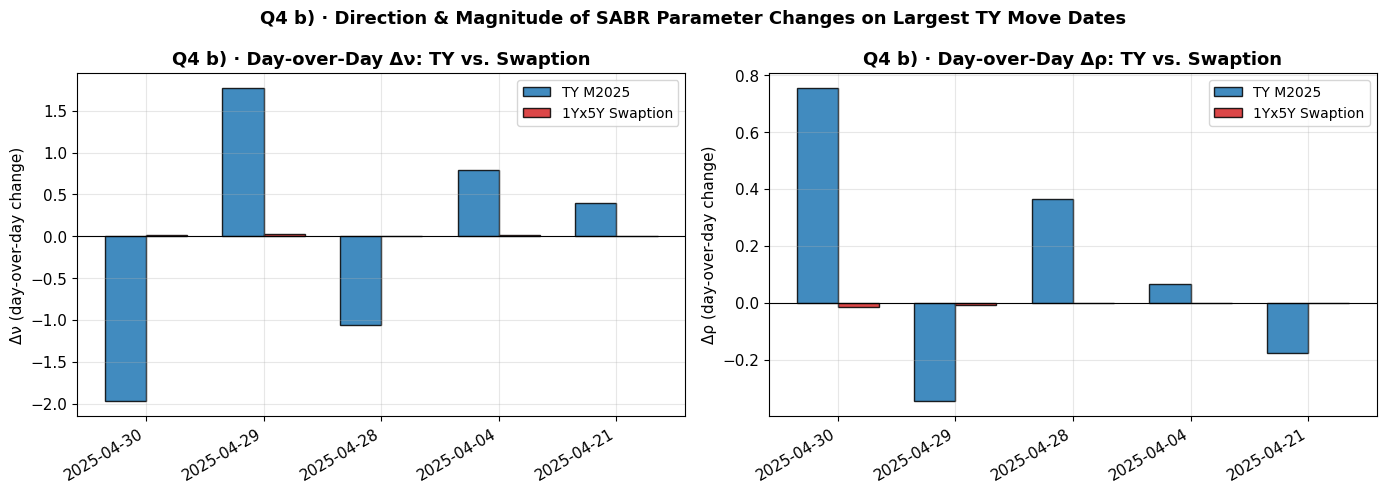

In [18]:
# 1. Swaption day-over-day diffs (computed on full April series)
sabr_sw_sorted = sabr_sw.sort_values("date").copy()
sabr_sw_sorted["d_nu_sw"]  = sabr_sw_sorted["nu"].diff()
sabr_sw_sorted["d_rho_sw"] = sabr_sw_sorted["rho"].diff()

# 2. TY M2025 diffs on the FULL series first, then filter to April
sabr_M2025_full = sabr_M2025.sort_values("date").reset_index(drop=True).copy()
sabr_M2025_full["d_nu_ty"]  = sabr_M2025_full["nu"].diff()
sabr_M2025_full["d_rho_ty"] = sabr_M2025_full["rho"].diff()
sabr_M2025_full["score_ty"] = (sabr_M2025_full["d_nu_ty"].abs() +
                                sabr_M2025_full["d_rho_ty"].abs())

ty_apr_sorted = sabr_M2025_full[
    (sabr_M2025_full["date"] >= pd.Timestamp("2025-04-01")) &
    (sabr_M2025_full["date"] <= pd.Timestamp("2025-04-30"))
].copy()

# 3. Top-5 April dates by largest TY parameter jump
top_apr = (ty_apr_sorted.dropna(subset=["score_ty"])
           .nlargest(5, "score_ty")
           [["date", "d_nu_ty", "d_rho_ty", "score_ty"]]
           .reset_index(drop=True))

# 4. Merge with swaption diffs
q4b = top_apr.merge(
    sabr_sw_sorted[["date", "d_nu_sw", "d_rho_sw"]],
    on="date", how="left"
).rename(columns={
    "d_nu_ty":  "Δν TY",
    "d_rho_ty": "Δρ TY",
    "d_nu_sw":  "Δν Swaption",
    "d_rho_sw": "Δρ Swaption",
    "score_ty": "Score (TY)",
})

display(q4b.set_index("date").round(5)
        .style.set_caption(
            "Q4 b) · SABR Parameter Changes on Largest TY Move Dates: "
            "TY vs. Swaption"))

# 5. Direction-agreement and magnitude-ratio columns
q4b["ν agree direction?"] = q4b.apply(
    lambda r: ("✓ Yes" if (np.isfinite(r["Δν TY"]) and np.isfinite(r["Δν Swaption"])
                           and np.sign(r["Δν TY"]) == np.sign(r["Δν Swaption"]))
               else ("✗ No" if (np.isfinite(r["Δν TY"]) and np.isfinite(r["Δν Swaption"]))
                    else "n/a")),
    axis=1
)
q4b["ρ agree direction?"] = q4b.apply(
    lambda r: ("✓ Yes" if (np.isfinite(r["Δρ TY"]) and np.isfinite(r["Δρ Swaption"])
                           and np.sign(r["Δρ TY"]) == np.sign(r["Δρ Swaption"]))
               else ("✗ No" if (np.isfinite(r["Δρ TY"]) and np.isfinite(r["Δρ Swaption"]))
                    else "n/a")),
    axis=1
)
q4b["ν |SW/TY| ratio"] = (q4b["Δν Swaption"].abs() / q4b["Δν TY"].abs()).round(3)
q4b["ρ |SW/TY| ratio"] = (q4b["Δρ Swaption"].abs() / q4b["Δρ TY"].abs()).round(3)

display(
    q4b.set_index("date").round(5)
    .style.set_caption(
        "Q4 b) · SABR Parameter Changes on Largest TY Move Dates: TY vs. Swaption\n"
        "(✓ = same direction; |SW/TY| ratio > 1 means swaption moved more than TY)"))

# 6. Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dates_str = [str(d.date()) for d in q4b["date"]]
x = np.arange(len(dates_str))
w = 0.35

for ax, param, col_ty, col_sw, ylabel in [
    (axes[0], "ν", "Δν TY", "Δν Swaption", "Δν (day-over-day change)"),
    (axes[1], "ρ", "Δρ TY", "Δρ Swaption", "Δρ (day-over-day change)"),
]:
    ty_vals = q4b[col_ty].fillna(0).to_numpy()
    sw_vals = q4b[col_sw].fillna(0).to_numpy()

    ax.bar(x - w/2, ty_vals, w, label="TY M2025",
           color="#1f77b4", edgecolor="black", alpha=0.85)
    ax.bar(x + w/2, sw_vals, w, label="1Yx5Y Swaption",
           color="#d62728", edgecolor="black", alpha=0.85)

    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(dates_str, rotation=30, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Q4 b) · Day-over-Day Δ{param}: TY vs. Swaption")
    ax.legend()

fig.suptitle(
    "Q4 b) · Direction & Magnitude of SABR Parameter Changes on Largest TY Move Dates",
    fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

### Q4. c) – Normalised Smile Overlay: TY Options vs. 1Yx5Y Swaptions

We overlay vol / σ_ATM against standardised log-moneyness for multiple
April dates to compare the smile *shape* (not level) across products.

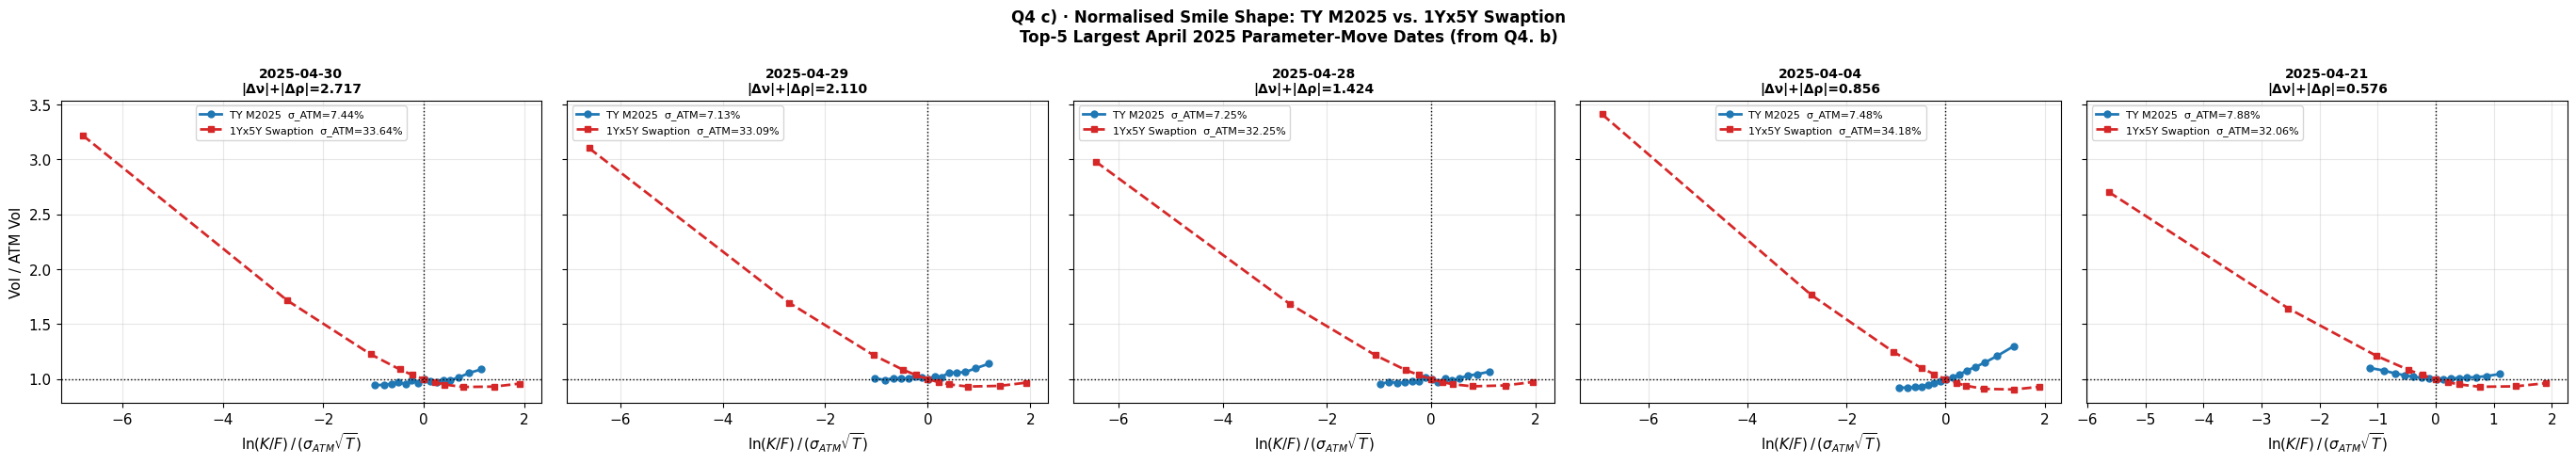

In [19]:
# Get the top 5 dates
q4c_dates = top_apr["date"].tolist()

n = len(q4c_dates)
fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 5), sharey=True)
if n == 1:
    axes = [axes]

for ax, dt in zip(axes, q4c_dates):
    score = float(top_apr.loc[top_apr["date"] == dt, "score_ty"].iloc[0])

    # TY M2025 smile
    ty_row  = ty_option_surfaces_M2025[ty_option_surfaces_M2025["date"] == dt].iloc[0]
    ty_sm   = build_smile(ty_row)
    ty_F_   = ty_row["Future Price"]
    ty_T_   = ty_row["Expiration Option"]
    ty_atm_ = atm_vol_from_row(ty_row)
    ty_x    = np.log(ty_sm["strike"] / ty_F_) / (ty_atm_ * np.sqrt(ty_T_))
    ty_y    = ty_sm["vol"] / ty_atm_
    ax.plot(ty_x, ty_y, "o-", color="#1f77b4", lw=2, ms=5,
            label=f"TY M2025  σ_ATM={ty_atm_*100:.2f}%")

    # 1Yx5Y Swaption smile
    sw_vr   = swaption_smile_black_vol_pct[swaption_smile_black_vol_pct["date"] == dt].iloc[0]
    sw_fr   = swaption_smile_atm_forward  [swaption_smile_atm_forward  ["date"] == dt].iloc[0]
    sw_sr   = swaption_smile_abs_strike_pct[swaption_smile_abs_strike_pct["date"] == dt].iloc[0]
    sw_F_   = float(sw_fr["atm_fwd_pct"]) / 100.0
    sw_T_   = 1.0
    sw_K_   = np.array([float(sw_sr[c]) / 100.0 for c in _sw_mono_cols])
    sw_v_   = np.array([float(sw_vr[c]) / 100.0 for c in _sw_mono_cols])
    sw_atm_ = float(sw_vr[_sw_atm_col]) / 100.0
    sw_x    = np.log(sw_K_ / sw_F_) / (sw_atm_ * np.sqrt(sw_T_))
    sw_y    = sw_v_ / sw_atm_
    ax.plot(sw_x, sw_y, "s--", color="#d62728", lw=2, ms=5,
            label=f"1Yx5Y Swaption  σ_ATM={sw_atm_*100:.2f}%")

    ax.axhline(1, color="black", ls=":", lw=1)
    ax.axvline(0, color="black", ls=":", lw=1)
    ax.set_title(f"{dt.date()}\n|Δν|+|Δρ|={score:.3f}", fontsize=10)
    ax.set_xlabel(r"$\ln(K/F)\,/\,(\sigma_{ATM}\sqrt{T})$")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Vol / ATM Vol")
fig.suptitle(
    "Q4 c) · Normalised Smile Shape: TY M2025 vs. 1Yx5Y Swaption\n"
    "Top-5 Largest April 2025 Parameter-Move Dates (from Q4. b)",
    fontsize=12, fontweight="bold"
)
fig.tight_layout(); plt.show()

### Q4. d) – Reasons for Cross-Product Differences

## Question 5 – Practical Implications: Augmented Delta Across Regimes

**Setup:**  
A dealer is short a put on TY futures struck 50 bp below ATM.  
We interpret "50 basis points below ATM" as \( K = F - 0.50 \) (0.5 futures-price points).

**Black delta** (signed):  
$$
\Delta_{\text{Black}} = -N(-d_1), \quad 
d_1 = \frac{\ln(F/K) + \frac{1}{2}\sigma^2 T}{\sigma\sqrt{T}}
$$

**SABR augmented delta** (Hagan et al.):  
$$
\Delta_{\text{SABR}} = \Delta_{\text{Black}} + V \cdot \frac{\partial \sigma}{\partial F}
$$
where $( V = $) Black vega $( = F \cdot \varphi(d_1) \cdot \sqrt{T} $), and $( \frac{\partial \sigma}{\partial F} $) is computed by central finite difference with bump $( \epsilon = 0.0001 $) in futures price (keeping $( \alpha, \beta, \rho, \nu $) fixed).

In [20]:
# Helper function used throughout Q5
def black_greeks(F, K, sigma, T):
    """Black-76 put delta and vega (undiscounted, futures convention)."""
    if sigma <= 0 or T <= 0 or K <= 0:
        return {"d1": np.nan, "delta_black": np.nan, "vega": np.nan}
    d1     = (np.log(F/K) + 0.5*sigma**2*T) / (sigma*np.sqrt(T))
    delta  = norm.cdf(d1) - 1.0          # signed put delta = N(d1) – 1
    vega   = F * norm.pdf(d1) * np.sqrt(T)
    return {"d1": d1, "delta_black": delta, "vega": vega}


def sabr_augmented_delta(F, K, T, alpha, beta, rho, nu, eps=1e-4):
    """
    Compute SABR augmented put delta via central finite difference on F.
    ∂σ/∂F ≈ [σ(F+ε,K) – σ(F–ε,K)] / (2ε)
    """
    sigma_mid = sabr_implied_vol(F,      K, T, alpha, beta, rho, nu)
    sigma_up  = sabr_implied_vol(F+eps,  K, T, alpha, beta, rho, nu)
    sigma_dn  = sabr_implied_vol(F-eps,  K, T, alpha, beta, rho, nu)

    if not all(np.isfinite([sigma_mid, sigma_up, sigma_dn])):
        return {"delta_black": np.nan, "delta_sabr": np.nan, "correction": np.nan,
                "sigma": np.nan, "dsigma_dF": np.nan, "vega": np.nan}

    dsigma_dF = (sigma_up - sigma_dn) / (2.0 * eps)
    gr        = black_greeks(F, K, sigma_mid, T)
    correction = gr["vega"] * dsigma_dF
    delta_sabr = gr["delta_black"] + correction

    return {
        "sigma": sigma_mid, "dsigma_dF": dsigma_dF,
        "vega":  gr["vega"],
        "delta_black":  gr["delta_black"],
        "correction":   correction,
        "delta_sabr":   delta_sabr,
    }

### Q5. a) – Black Delta and SABR Augmented Delta: Volatile vs. Calm Regime

**Volatile date**: the M2025 date with highest ATM vol (inside the April 2025 tariff episode).

**Calm date**: the M2025 date with the lowest ATM vol and below-median parameter change score.

In [21]:
# Volatile date: highest sigma_atm in M2025
sabr_M2025_clean = sabr_M2025.dropna(subset=["sigma_atm","rho","nu","alpha"])
volatile_row = sabr_M2025_clean.loc[sabr_M2025_clean["sigma_atm"].idxmax()]
volatile_date = volatile_row["date"]

# Calm date: lowest sigma_atm in the low-change-score half, EXCLUDING near-expiry dates
m2025_w_score = sabr_M2025_clean.sort_values("date").copy()
m2025_w_score["d_nu"] = m2025_w_score["nu"].diff()
m2025_w_score["d_rho"] = m2025_w_score["rho"].diff()
m2025_w_score["score"] = m2025_w_score["d_nu"].abs() + m2025_w_score["d_rho"].abs()

# Exclude near-expiry (T < 0.05 yr ≈ ~2.5 weeks)
calm_pool = m2025_w_score[
    (m2025_w_score["score"] <= m2025_w_score["score"].quantile(0.50)) &
    (m2025_w_score["T"] > 0.05)
]
calm_row = calm_pool.loc[calm_pool["sigma_atm"].idxmin()]
calm_date = calm_row["date"]

# Display the dates with their ATM volatility
dates_df = pd.DataFrame({
    "Type": ["Volatile", "Calm"],
    "Date": [volatile_date.date(), calm_date.date()],
    "ATM Vol (%)": [volatile_row['sigma_atm'] * 100, calm_row['sigma_atm'] * 100]
})

display(dates_df.style.set_caption("Q5 a) · Volatile and Calm Dates with ATM Volatility"))


# Compute deltas for each date
def compute_deltas_for_date(dt, sabr_df, surface_df):
    """Return delta table for a given date."""
    cal  = sabr_df[sabr_df["date"] == dt].iloc[0]
    surf = surface_df[surface_df["date"] == dt].iloc[0]
    F    = float(surf["Future Price"])
    T    = float(surf["Expiration Option"])
    K    = F - 0.50          # 50 bp below ATM in futures-price space

    out  = sabr_augmented_delta(
        F, K, T,
        alpha=float(cal["alpha"]), beta=BETA,
        rho=float(cal["rho"]), nu=float(cal["nu"])
    )
    out.update({"date": dt, "F": F, "K": K, "T": T,
                "alpha": cal["alpha"], "rho": cal["rho"], "nu": cal["nu"],
                "sigma_atm": cal["sigma_atm"]})
    return out


res_volatile = compute_deltas_for_date(
    volatile_date, sabr_M2025, ty_option_surfaces_M2025)
res_calm     = compute_deltas_for_date(
    calm_date,     sabr_M2025, ty_option_surfaces_M2025)

q5_df = pd.DataFrame([res_volatile, res_calm]).set_index("date")
display(
    q5_df[["F","K","T","sigma_atm","alpha","rho","nu",
           "sigma","delta_black","vega","dsigma_dF","correction","delta_sabr"]]
    .round(6)
    .style.set_caption("Q5a · Black vs. SABR Augmented Put Delta  (K = F – 0.50)")
)

,Type,Date,ATM Vol (%)
0,Volatile,2025-04-11,8.459150
1,Calm,2025-03-24,6.029550


,F,K,T,sigma_atm,alpha,rho,nu,sigma,delta_black,vega,dsigma_dF,correction,delta_sabr
date,,,,,,,,,,,,,
2025-04-11 00:00:00,109.734375,109.234375,0.115644,0.084591,0.849439,-0.008353,2.117584,0.084929,-0.431497,14.667214,0.000683,0.010017,-0.421479
2025-03-24 00:00:00,110.546875,110.046875,0.164959,0.060296,0.621345,0.257660,1.267636,0.059697,-0.421095,17.560513,-0.001288,-0.022610,-0.443705


### Q5. b) – Hedge-Ratio Correction: Magnitude and Economic Significance

In [22]:
q5b = pd.DataFrame({
    "Regime":     ["Volatile", "Calm"],
    "Date":       [volatile_date.date(), calm_date.date()],
    "ATM Vol (%)": [res_volatile["sigma_atm"]*100, res_calm["sigma_atm"]*100],
    "σ(K) SABR (%)":  [res_volatile["sigma"]*100, res_calm["sigma"]*100],
    "Δ_Black":    [res_volatile["delta_black"], res_calm["delta_black"]],
    "Δ_SABR":     [res_volatile["delta_sabr"],  res_calm["delta_sabr"]],
    "Correction": [res_volatile["correction"],   res_calm["correction"]],
    "Correction % of |Δ_Black|": [
        res_volatile["correction"] / abs(res_volatile["delta_black"]) * 100,
        res_calm   ["correction"] / abs(res_calm   ["delta_black"]) * 100,
    ],
})

display(q5b.set_index("Regime").round(6)
        .style.set_caption(
            "Q5b · SABR Hedge Ratio Correction vs. Black Delta: "
            "Volatile vs. Calm Regime"))

,Date,ATM Vol (%),σ(K) SABR (%),Δ_Black,Δ_SABR,Correction,Correction % of |Δ_Black|
Regime,,,,,,,
Volatile,2025-04-11,8.459150,8.492948,-0.431497,-0.421479,0.010017,2.321533
Calm,2025-03-24,6.029550,5.969658,-0.421095,-0.443705,-0.022610,-5.369310


### add a few more days

### Q5. c) – Implications for Hedging and Recalibration Policy